<a href="https://colab.research.google.com/github/madumos/Analise_de_Score_Data_Girls_Finance/blob/main/Projeto_Final_Data_Girls_An%C3%A1lise_de_Score_de_Cr%C3%A9dito.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introdução

Este projeto foi desenvolvido como desafio final da Trilha de Analista de Dados do Bootcamp [RE]Start.

A concessão de crédito é um dos motores do mercado financeiro, mas exige inteligência para mitigar riscos. Atuando como Analista de Dados para a fintech Data Girls Finance , o objetivo principal foi explorar informações financeiras, comportamentais e cadastrais dos clientes para identificar padrões associados às classificações de score de crédito.


 Trataremos essa base para responder as seguintes perguntas:

1. Qual perfil tem maior risco de inadimplência (baixo score)?

2. Quais fatores (exemplo: salário, idade, overtime etc.) mais influenciam em clientes com score “Poor”?

3. Existe relação entre variáveis relevantes, como renda anual, quantidade de contas bancárias, número de cartões de crédito, empréstimos e classificação de score?

4. Clientes com maior atraso médio de pagamento tendem a apresentar pior classificação de crédito?

## 1. Leitura & Exploração Inicial



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import  re
import kagglehub

In [ ]:
path = kagglehub.dataset_download("parisrohan/credit-score-classification")

df = pd.read_csv('/kaggle/input/credit-score-classification/train.csv', low_memory=False)

df.head(20)

Using Colab cache for faster access to the 'credit-score-classification' dataset.


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172331195294,!@9#%8,340.4792117872438,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.3440674122349,Low_spent_Small_value_payments,244.5653167062043,Good
7,0x1609,CUS_0xd40,August,NaN,23,#F%$D@*&8,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785216509052056,High_spent_Medium_value_payments,358.12416760938714,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28_,004-07-5839,_______,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825168246,Low_spent_Small_value_payments,470.69062692529184,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.39123782853101,High_spent_Large_value_payments,484.5912142650067,Good


In [ ]:
## Ver colunas que não apareceram na visualização de cima, quero entender o conteúdo de todas as colunas antes de começar

df[['Customer_ID','Num_Credit_Card','Interest_Rate','Num_of_Loan','Type_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment','Changed_Credit_Limit', 'Num_Credit_Inquiries']].head(20)


,Customer_ID,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries
0,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,11.27,4.0
1,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",-1,NaN,11.27,4.0
2,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,7,_,4.0
3,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5,4,6.27,4.0
4,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6,NaN,11.27,4.0
5,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",8,4,9.27,4.0
6,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,8_,11.27,4.0
7,CUS_0xd40,4,3,4,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3,6,11.27,4.0
8,CUS_0x21b1,4,6,1,Credit-Builder Loan,3,4,5.42,2.0
9,CUS_0x21b1,4,6,1,Credit-Builder Loan,7,1,7.42,2.0


In [ ]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [ ]:
nulos = df.isnull().sum()
porcentagem_nulos = (nulos / len(df)) * 100
porcentagem_nulos[nulos>0]

,0
Name,9.985
Monthly_Inhand_Salary,15.002
Type_of_Loan,11.408
Num_of_Delayed_Payment,7.002
Num_Credit_Inquiries,1.965
Credit_History_Age,9.030
Amount_invested_monthly,4.479
Monthly_Balance,1.200


## 2. Limpeza & Preparação dos Dados

O objetivo central desta etapa é preservar o máximo de informações originais para garantir uma análise fidedigna. Como a base de dados registra múltiplas entradas para o mesmo cliente, a estratégia adotada foi utilizar o histórico de cada indivíduo para preencher as suas próprias informações ausentes.

Como não há valores nulos na coluna Customer_ID, ela servirá como a chave primária confiável para agrupar as linhas e propagar os dados cadastrais fixos de cada cliente ao longo do tempo.


### 2.1 Correção de Tipos de Dados

A análise preliminar do dataframe revelou que diversas variáveis numéricas foram lidas pelo Pandas como strings. A conversão destes dados para o formato adequado é um pré-requisito fundamental para permitir a limpeza e as análises estatísticas subsequentes. Além disso, variáveis textuais apresentam inconsistências de preenchimento, falta de padronização e valores nulos ocultos.


#### 1º Grupo: Variáveis numéricas corrompidas por caracteres inválidos ou ruído

* Age
* Annual_Income
* Num_of_Loan
* Num_of_Delayed_Payment
* Changed_Credit_Limit
* Outstanding_Debt
* Amount_invested_monthly
* Monthly_Balance


In [ ]:
colunas_numericas_sujas = ['Age', 'Annual_Income', 'Num_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt', 'Amount_invested_monthly', 'Monthly_Balance']

# Retirada de caracteres que não são números das variáveis

df[colunas_numericas_sujas] = df[colunas_numericas_sujas].apply(lambda x: x.str.replace(r'[^0-9.-]', '', regex=True))

df[colunas_numericas_sujas] = df[colunas_numericas_sujas].apply(pd.to_numeric, errors='coerce')


In [ ]:
df[colunas_numericas_sujas].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      100000 non-null  int64  
 1   Annual_Income            100000 non-null  float64
 2   Num_of_Loan              100000 non-null  int64  
 3   Num_of_Delayed_Payment   92998 non-null   float64
 4   Changed_Credit_Limit     97909 non-null   float64
 5   Outstanding_Debt         100000 non-null  float64
 6   Amount_invested_monthly  95521 non-null   float64
 7   Monthly_Balance          98800 non-null   float64
dtypes: float64(6), int64(2)
memory usage: 6.1 MB


#### 2º Grupo: Variáveis Textuais com Inconsistências ou Nulos

Engloba colunas do tipo string que apresentam falhas de preenchimento, categorias não padronizadas ou valores nulos mascarados com espaços em branco ou caracteres especiais.

* SSN
* Occupation
* Payment_Behaviour
* Credit_Mix

In [ ]:
# Para o SSN: padronização estrutural e validação dos dados para garantir que todos os registros respeitem o formato oficial

df['SSN'] = df['SSN'].where(df['SSN'].str.match(r'^\d{3}-\d{2}-\d{4}$'), np.nan)

# Para as demais, padronização estrutural e validação dos dados para garantir que todos os registros respeitem o formato oficial.

df['Occupation'] = df['Occupation'].replace(r'.*[_].*', np.nan, regex=True)

df['Payment_Behaviour'] = df['Payment_Behaviour'].replace(r'.*[#%$@*&!].*', np.nan, regex=True)

df['Credit_Mix'] = df['Credit_Mix'].replace(r'.*[_].*', np.nan, regex=True)



In [ ]:
# Visualização da Correção
df.head(10)

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,NaN,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.415295,High_spent_Small_value_payments,312.494089,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521,Low_spent_Medium_value_payments,331.209863,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.458074,Low_spent_Small_value_payments,223.451310,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153,High_spent_Medium_value_payments,341.489231,Good
5,0x1607,CUS_0xd40,June,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,27.262259,22 Years and 6 Months,No,49.574949,62.430172,NaN,340.479212,Good
6,0x1608,CUS_0xd40,July,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,22.537593,22 Years and 7 Months,No,49.574949,178.344067,Low_spent_Small_value_payments,244.565317,Good
7,0x1609,CUS_0xd40,August,NaN,23,NaN,Scientist,19114.12,1824.843333,3,...,Good,809.98,23.933795,NaN,No,49.574949,24.785217,High_spent_Medium_value_payments,358.124168,Standard
8,0x160e,CUS_0x21b1,January,Rick Rothackerj,28,004-07-5839,NaN,34847.84,3037.986667,2,...,Good,605.03,24.464031,26 Years and 7 Months,No,18.816215,104.291825,Low_spent_Small_value_payments,470.690627,Standard
9,0x160f,CUS_0x21b1,February,Rick Rothackerj,28,004-07-5839,Teacher,34847.84,3037.986667,2,...,Good,605.03,38.550848,26 Years and 8 Months,No,18.816215,40.391238,High_spent_Large_value_payments,484.591214,Good


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  int64  
 5   SSN                       94428 non-null   object 
 6   Occupation                86706 non-null   object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              88592 non-null   ob

### Identificação e Tratamento de Anomalias e Outliers

A análise será focada nas variáveis numéricas para detetar inconsistências lógicas e valores atípicos que fogem à realidade do negócio.

A estratégia adotada consiste em invalidar estes dados corrompidos em convertendo-os em valores nulos.

In [ ]:
#Selecionamos todas as colunas númericas para fazer uma primeira avaliação

colunas_numericas = df.select_dtypes(include=['number']).columns

df[colunas_numericas].describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,92998.000000,97909.000000,98035.000000,100000.000000,100000.000000,100000.000000,95521.000000,9.880000e+04
mean,110.649700,1.764157e+05,4194.170850,17.091280,22.47443,72.466040,3.009960,21.068780,30.923342,10.389025,27.754251,1426.220376,32.285173,1403.118217,637.412998,-3.036437e+22
std,686.244717,1.429618e+06,3183.686167,117.404834,129.05741,466.422621,62.647879,14.860104,226.031892,6.789496,193.177339,1155.129026,5.116875,8306.041270,2043.319327,3.181295e+24
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.00000,1.000000,-100.000000,-5.000000,-3.000000,-6.490000,0.000000,0.230000,20.000000,0.000000,0.000000,-3.333333e+26
25%,24.000000,1.945750e+04,1625.568229,3.000000,4.00000,8.000000,1.000000,10.000000,9.000000,5.320000,3.000000,566.072500,28.052567,30.306660,74.534002,2.700922e+02
50%,33.000000,3.757861e+04,3093.745000,6.000000,5.00000,13.000000,3.000000,18.000000,14.000000,9.400000,6.000000,1166.155000,32.305784,69.249473,135.925682,3.367192e+02
75%,42.000000,7.279092e+04,5957.448333,7.000000,7.00000,20.000000,5.000000,28.000000,18.000000,14.870000,9.000000,1945.962500,36.496663,161.224249,265.731733,4.702202e+02
max,8698.000000,2.419806e+07,15204.633333,1798.000000,1499.00000,5797.000000,1496.000000,67.000000,4397.000000,36.970000,2597.000000,4998.070000,50.000000,82331.000000,10000.000000,1.602041e+03


<Axes: >

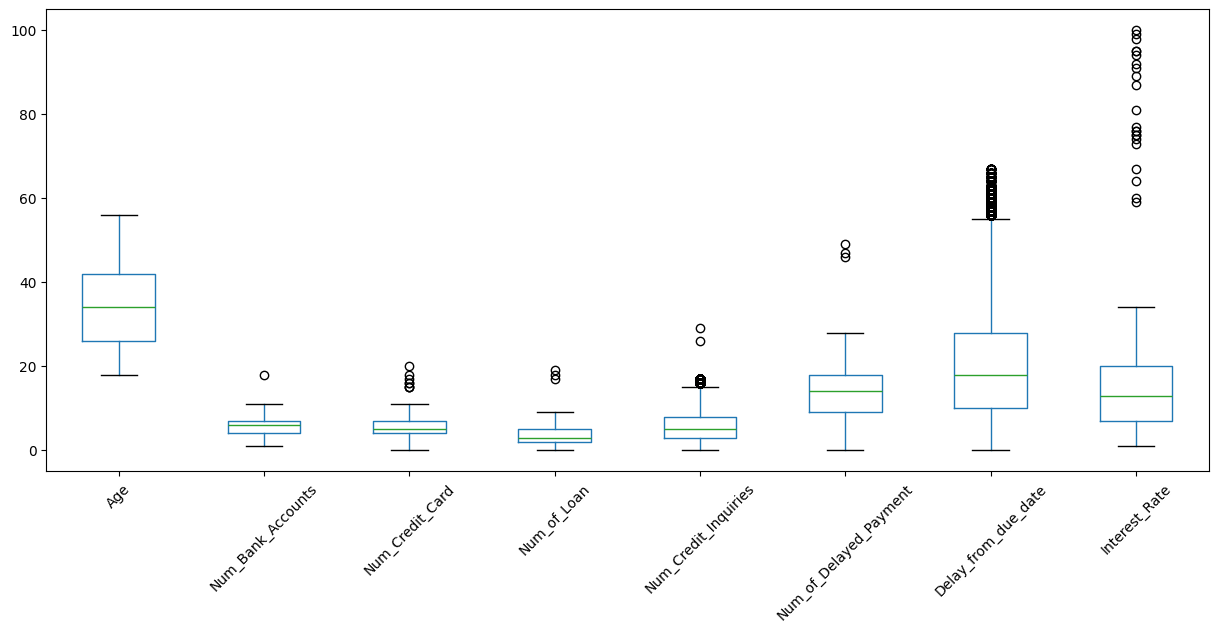

In [ ]:
# Tratamento das Variáveis Discretas

variaveis_discretas = {
    'Age': (18, 90),                   # Idade mínima para concessão de crédito
    'Num_Bank_Accounts': (1, 20),      # Pré-requisito mínimo de 1 conta bancária
    'Num_Credit_Card': (0, 20),        # Abrange a ausência de cartões
    'Num_of_Loan': (0, 20),
    'Num_Credit_Inquiries': (0, 30),
    'Num_of_Delayed_Payment': (0, 50),
    'Delay_from_due_date': (0, 70),    # Limite estipulado englobando todos os valores positivos na base
    'Interest_Rate': (0, 100)          # Taxas restritas ao intervalo de 0% a 100%
}

for coluna, (min_val, max_val) in variaveis_discretas.items():

    df[coluna] = df[coluna].where(df[coluna].between(min_val, max_val), np.nan)


df.boxplot(column=list(variaveis_discretas.keys()), figsize=(15, 6), grid=False, rot=45)

<Axes: >

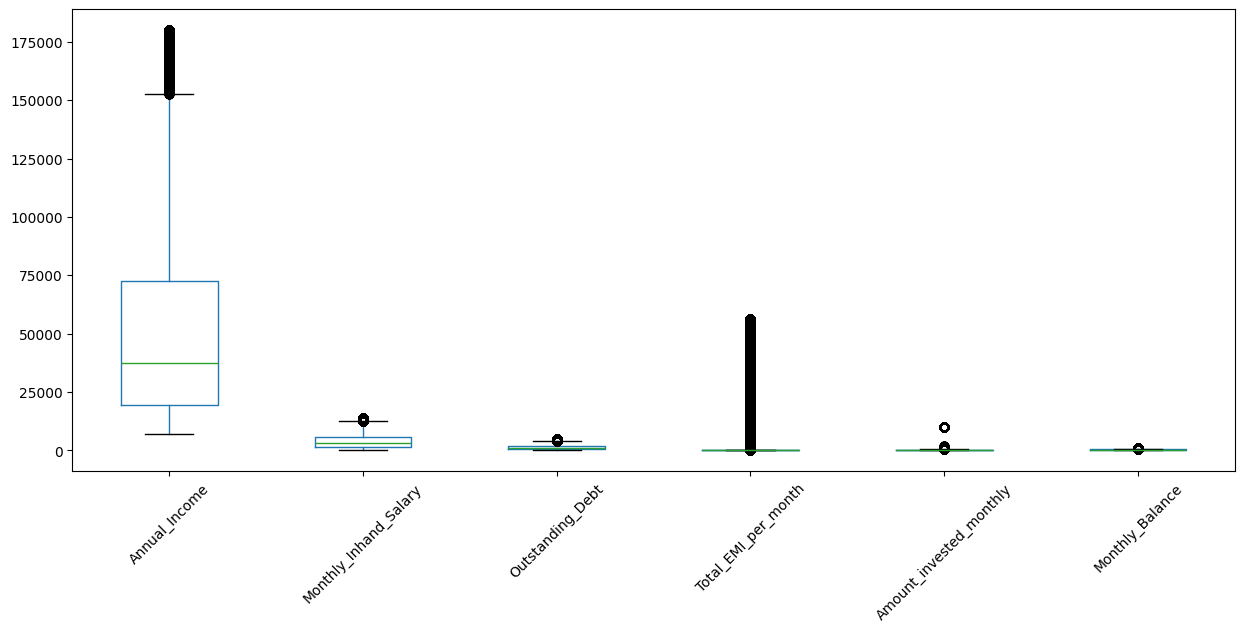

In [ ]:
# Tratamento das Variáveis Contínuas

# Winsorização para mitigação de valores extremos

colunas_financeiras_estritamente_positivas = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Outstanding_Debt',
    'Total_EMI_per_month',
    'Amount_invested_monthly'
]

coluna_com_saldo_negativo = ['Monthly_Balance'] # O cliente pode usar o cheque especial


variaveis_continuas = colunas_financeiras_estritamente_positivas + coluna_com_saldo_negativo


for col in colunas_financeiras_estritamente_positivas:

  limite_superior = df[col].quantile(0.99)

  df[col] = df[col].clip(lower=0, upper=limite_superior)


for col in coluna_com_saldo_negativo:

  limite_inferior = df[col].quantile(0.01)

  limite_superior = df[col].quantile(0.99)

  df[col] = df[col].clip(lower=limite_inferior, upper=limite_superior)


df.boxplot(column=variaveis_continuas, figsize=(15, 6), grid=False, rot=45)


### 2.3 Tratamento de Nulos

Uma vez que o dataset possui múltiplas observações temporais para os mesmos indivíduos, a estratégia primária para lidar com a ausência de dados será a imputação baseada no histórico do próprio cliente.





In [ ]:
nulos = df.isnull().sum()
porcentagem_nulos = (nulos / len(df)) * 100
porcentagem_nulos[nulos>0]

,0
Name,9.985
Age,8.487
SSN,5.572
Occupation,13.294
Monthly_Inhand_Salary,15.002
Num_Bank_Accounts,5.663
Num_Credit_Card,2.263
Interest_Rate,2.012
Num_of_Loan,4.345
Type_of_Loan,11.408


 1º Grupo: Variáveis Estáticas

Este grupo engloba os atributos que permanecem inalterados ao longo da janela temporal de observação do dataset.

A estratégia consiste em utilizar o Customer_ID para agrupar os registos de cada indivíduo, desta forma, utilizamos os meses em que a informação está preenchida para suprir as lacunas nos meses em que o dado está ausente, garantindo a coesão do perfil do cliente.

* Name

* Age

* SSN

* Occupation

* Type_of_Loan








In [ ]:
variaveis_fixas = ['Name',
                   'Age',
                   'SSN',
                   'Occupation',
                   'Type_of_Loan'
                   ]

df[variaveis_fixas] = df.groupby('Customer_ID')[variaveis_fixas].ffill().bfill()


2º Grupo: Variáveis Financeiras e Comportamentais

Este grupo engloba variáveis numéricas contínuas e contagens de produtos financeiros. Uma vez que o comportamento financeiro e o nível de endividamento tendem a manter um padrão específico para cada cliente ao longo do tempo, o preenchimento de dados ausentes com métricas globais distorceria a análise.

A estratégia adotada consiste em agrupar os dados por Customer_ID e imputar os valores nulos utilizando a mediana intragrupo do próprio indivíduo, garantindo que os dados imputados reflitam com precisão a realidade financeira e o perfil de risco de cada cliente.


* Amount_invested_monthly

* Monthly_Balance

* Changed_Credit_Limit

* Num_Bank_Accounts

* Num_Credit_Card

* Num_of_Loan

* Interest_Rate

* Credit_Utilization_Ratio

* Total_EMI_per_month

* Monthly_Inhand_Salary

* Annual_Income

* Outstanding_Debt

* Num_of_Delayed_Payment

* Num_Credit_Inquiries

* Delay_from_due_date
    


In [ ]:
variaveis_mediana = [
    'Amount_invested_monthly',
    'Monthly_Balance',
    'Changed_Credit_Limit',
    'Num_Bank_Accounts',
    'Num_Credit_Card',
    'Num_of_Loan',
    'Interest_Rate',
    'Credit_Utilization_Ratio',
    'Total_EMI_per_month',
    'Monthly_Inhand_Salary',
    'Annual_Income',
    'Outstanding_Debt',
    'Num_of_Delayed_Payment',
    'Num_Credit_Inquiries',
    'Delay_from_due_date'
    ]

df[variaveis_mediana] = df.groupby('Customer_ID')[variaveis_mediana].transform(lambda x: x.fillna(x.median()))

# Preenchimento de nulos residuais com a mediana global

df[variaveis_mediana] = df[variaveis_mediana].fillna(df[variaveis_mediana].median())



In [ ]:
nulos = df.isnull().sum()
porcentagem_nulos = (nulos / len(df)) * 100
porcentagem_nulos[nulos>0]

,0
Credit_Mix,20.195
Credit_History_Age,9.030
Payment_Behaviour,7.600


3º Grupo: Variáveis Categóricas

Para as variáveis qualitativas, métricas aritméticas como média ou mediana não são aplicáveis. Portanto, a estratégia mais rigorosa para o tratamento de valores nulos nestes casos é a imputação pela moda, calculada com base no histórico individual de cada cliente.

Esta técnica garante que as lacunas sejam preenchidas respeitando o padrão de comportamento predominante do próprio indivíduo, evitando a contaminação do perfil com características de terceiros.

* Payment_Behaviour
* Credit_Mix

In [ ]:
df['Payment_Behaviour'] = df.groupby('Customer_ID')['Payment_Behaviour'].transform(lambda x: x.fillna(x.mode()[0]))

df['Credit_Mix'] = df.groupby('Customer_ID')['Credit_Mix'].transform(lambda x: x.fillna(x.mode()[0]))

4º Grupo: Variável Temporal

A variável 'Credit_History_Age' encontra-se originalmente num formato de texto não estruturado, o que inviabiliza análise estatística direta. Como o histórico de crédito é uma variável contínua com progressão linear, o tratamento dos valores nulos será feita através da interpolação matemática.

*ex: X Years and Y Months*








In [ ]:
# Estruturação Temporal: Ordenação cronológica da base de dados por Cliente e por Mês, garantindo a integridade da linha de tempo individual

ordem_meses = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August']

df['Month'] = pd.Categorical(df['Month'], categories=ordem_meses, ordered=True)

df = df.sort_values(by=['Customer_ID', 'Month']).reset_index(drop=True)


# Extração e Conversão: Utilização de Regex para extrair anos e meses do texto

df['Anos_de_Histórico_de_Crédito'] = df['Credit_History_Age'].str.extract(r'(\d+)\s*Years').astype(float)

df['Meses_de_Histórico_de_Crédito'] = df['Credit_History_Age'].str.extract(r'(\d+)\s*Months').astype(float)

df['Credit_History_Months'] = (df['Anos_de_Histórico_de_Crédito'] * 12) + df['Meses_de_Histórico_de_Crédito']


# Interpolação Linear: Cálculo do valor exato do histórico em falta com base na progressão dos meses adjacentes

df['Credit_History_Months'] = df.groupby('Customer_ID')['Credit_History_Months'].transform(
    lambda x: x.fillna(x.interpolate(method='linear', limit_direction='both')))


# Padronização: Reconversão do resultado final para uma variável 'Credit_History_Age' em float, facilitando a leitura de negócio no Dashboard final.

df['Credit_History_Months'] = df['Credit_History_Months'].astype(int)

df['Credit_History_Years'] = round(df['Credit_History_Months'] / 12, 2)


# Remoção das colunas temporárias

colunas_temporarias = ['Anos_de_Histórico_de_Crédito', 'Meses_de_Histórico_de_Crédito','Credit_History_Age']

df = df.drop(columns=colunas_temporarias, errors='ignore')


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   ID                        100000 non-null  object  
 1   Customer_ID               100000 non-null  object  
 2   Month                     100000 non-null  category
 3   Name                      100000 non-null  object  
 4   Age                       100000 non-null  float64 
 5   SSN                       100000 non-null  object  
 6   Occupation                100000 non-null  object  
 7   Annual_Income             100000 non-null  float64 
 8   Monthly_Inhand_Salary     100000 non-null  float64 
 9   Num_Bank_Accounts         100000 non-null  float64 
 10  Num_Credit_Card           100000 non-null  float64 
 11  Interest_Rate             100000 non-null  float64 
 12  Num_of_Loan               100000 non-null  float64 
 13  Type_of_Loan              1000

### 2.4 Validação e Remoção de Registros Duplicados

Dado o caráter longitudinal do dataset, apenas linhas com 100% de correspondência em todas as colunas serão classificadas como duplicatas.

In [ ]:
total_duplicadas = df.duplicated().sum()
print(f"Total de linhas 100% duplicadas: {total_duplicadas}")

Total de linhas 100% duplicadas: 0


### 2.5 Padronização de Dados


In [ ]:
# Variáveis de discretas serão tipadas como inteiros, enquanto as variáveis contínuas serão arredondadas para duas casas decimais.

valores_discretos = list(variaveis_discretas.keys())

df[valores_discretos] = df[valores_discretos].astype(int)

variaveis_continuas = df.select_dtypes(include=['float']).columns

df[variaveis_continuas] = df[variaveis_continuas].round(2)

# Para viabilizar uma análise visual, aplicaremos uma transformação logarítmica para normalizar a escala de alguns dados

df['Annual_Income_log'] = np.log1p(df['Annual_Income'])

df['Amount_invested_monthly_log'] = np.log1p(df['Amount_invested_monthly'])

df['Total_EMI_per_month_log'] = np.log1p(df['Total_EMI_per_month'])

### Visualização Final

In [ ]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Credit_History_Months,Credit_History_Years,Annual_Income_log,Amount_invested_monthly_log,Total_EMI_per_month_log
0,0x1628a,CUS_0x1000,January,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.16,6,...,42.94,244.75,Low_spent_Large_value_payments,252.92,Standard,122,10.17,10.329635,5.504315,3.782825
1,0x1628b,CUS_0x1000,February,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.16,6,...,42.94,176.13,High_spent_Small_value_payments,311.54,Poor,123,10.25,10.329635,5.176884,3.782825
2,0x1628c,CUS_0x1000,March,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.16,6,...,42.94,109.06,High_spent_Medium_value_payments,368.62,Poor,124,10.33,10.329635,4.701026,3.782825
3,0x1628d,CUS_0x1000,April,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.16,6,...,42.94,87.91,High_spent_Medium_value_payments,419.77,Poor,125,10.42,10.329635,4.487625,3.782825
4,0x1628e,CUS_0x1000,May,Alistair Barrf,18,913-74-1218,Lawyer,30625.94,2706.16,6,...,42.94,191.83,Low_spent_Large_value_payments,305.84,Poor,126,10.50,10.329635,5.261809,3.782825


## 3. Análise Exploratória (EDA) e Insights

Para começarmos, precisamos entender quais são as respostas que queremos tirar desses dados.

O objetivo desta etapa é fazer uma investigação direcionada para responder às perguntas de negócio do escopo do projeto, como: padrões comportamentais, correlações financeiras e os principais indicadores de risco que determinam a degradação ou elevação do Score de Crédito.


## 3.1. Perfil Socioeconômico e Comportamental do Cliente

Esta seção avalia a identidade socioeconômica do cliente, contrastando o seu poder de geração de receita com a sua real capacidade de gestão financeira e retenção de capital.



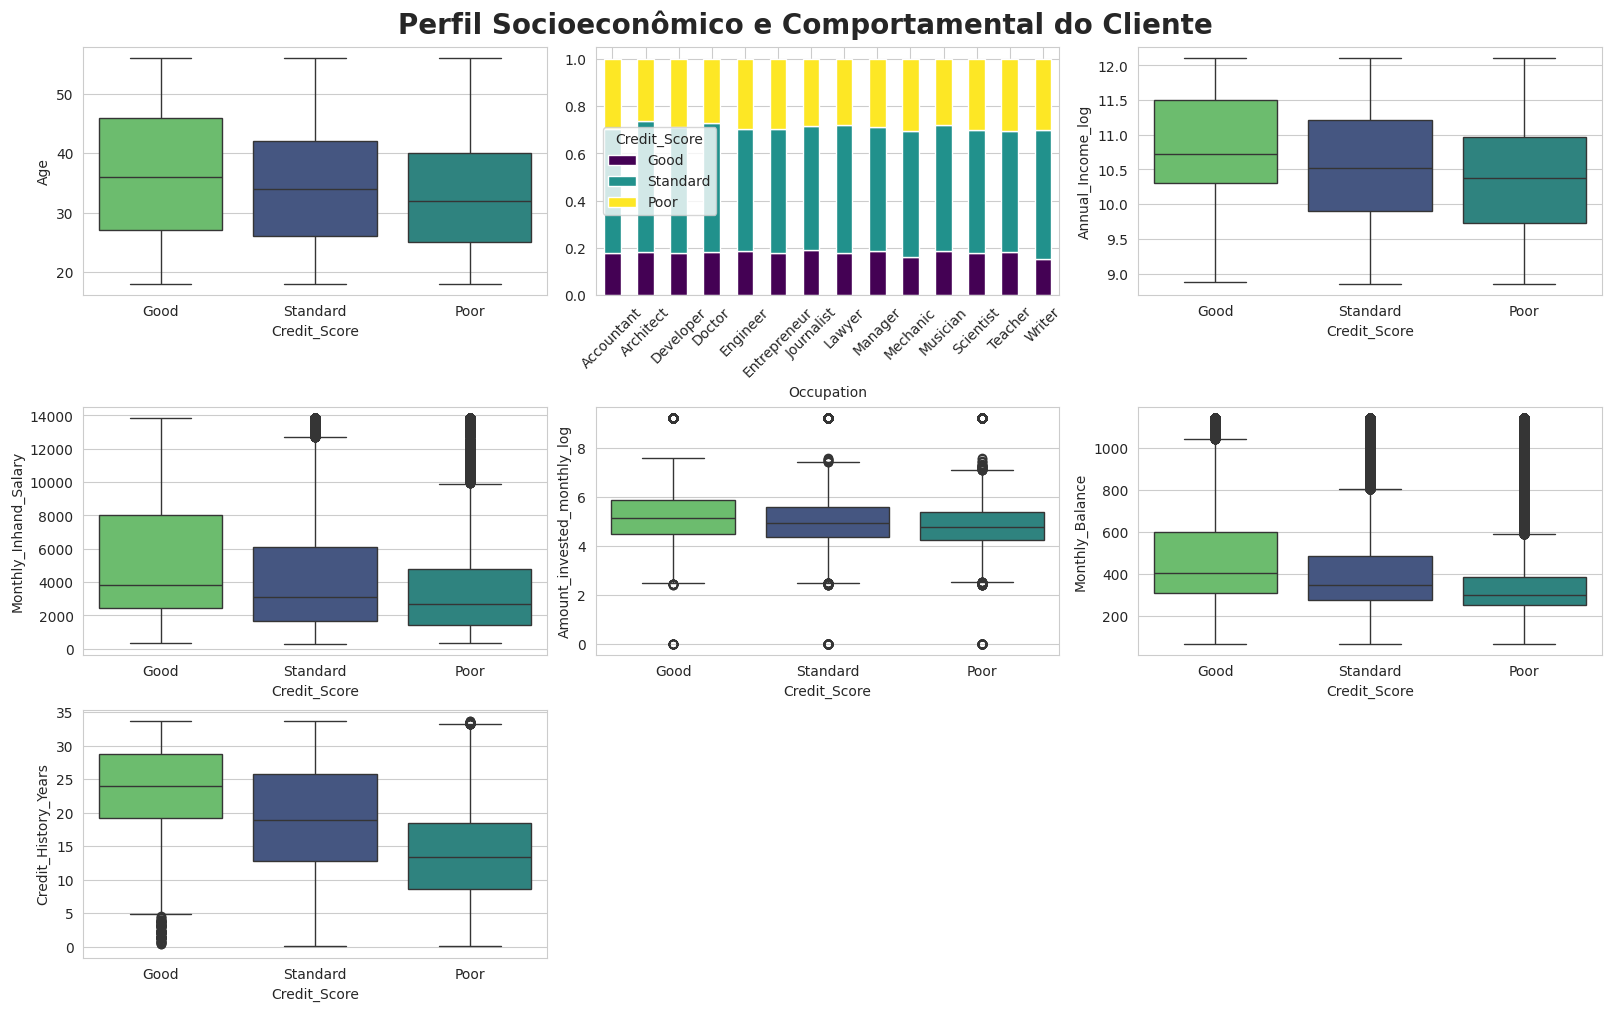

In [ ]:
ordem_score = ['Good', 'Standard', 'Poor']

sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 10), layout='constrained')
fig.suptitle('Perfil Socioeconômico e Comportamental do Cliente', fontsize=20, fontweight='bold')

# Idade
sns.boxplot(x='Credit_Score', y='Age', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 0])

# Profissão
pd.crosstab(df['Occupation'], df['Credit_Score'], normalize='index')[ordem_score].plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)

# Renda Anual
sns.boxplot(x='Credit_Score', y='Annual_Income_log', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 2])

# Salário Líquido Mensal

sns.boxplot(x='Credit_Score', y='Monthly_Inhand_Salary', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 0])

# Investimento Mensal

sns.boxplot(x='Credit_Score', y='Amount_invested_monthly_log', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 1])

# Saldo Mensal

sns.boxplot(x='Credit_Score', y='Monthly_Balance', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 2])

# Anos de Histórico de Crédito

sns.boxplot(x='Credit_Score', y='Credit_History_Years', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[2, 0])

axes[2, 1].set_visible(False)

axes[2, 2].set_visible(False)



* *Idade (Correlação Indireta):* A variável Idade apresenta impacto moderado na classificação de risco. No entanto, a análise multivariada indica que a Maturidade do Histórico de Crédito é decisiva. Clientes mais velhos tendem a possuir scores superiores não pela idade demográfica em si, mas pelo maior tempo de exposição e construção de histórico no mercado financeiro.


* *Profissão (Baixo Poder Preditivo):* A profissão do cliente apresentou impacto estatisticamente irrelevante para a determinação do risco, portanto, o cargo não é um discriminador de crédito válido para esta carteira.


* *Renda Anual e Salário (Baixa Correlação Direta):* Embora clientes com scores bons apresentem rendimentos levemente maiores, existe uma volumetria significativa de clientes com salários na faixa de alta renda classificados na categoria ruim.


* *Investimentos (Baixo Poder Preditivo):* As distribuições de aportes mensais são estatisticamente semelhantes entre as categorias de risco, não configurando um fator decisivo para o score.


* *Saldo Mensal(Variável Crítica e Decisiva):* O saldo residual em conta ao fim do mês demonstrou ser o fator de maior peso nesta análise. Clientes que mantêm um fluxo de caixa positivo consistente representam a esmagadora maioria dos scores de excelência.


#### **Insights:**

> **Gestão supera Faturamento**: A identidade ou salário de um cliente têm um peso significativamente menor do que a seu comportamento financeiro.

> **Alta Renda não garante Adimplência**: Salários elevados geram uma falsa sensação de segurança se não forem acompanhados de controle de despesas. A capacidade de manter saldo positivo é o preditor mais forte de um Score de Crédito saudável.




## 3.2. Comportamento de Consumo de Crédito

Esta seção investiga a forma como o cliente interage com os produtos de crédito disponíveis no mercado, avaliando o impacto em sua classificação de risco.



##### **Modalidades de Empréstimo**

Para viabilizar a análise individual de cada tipo de empréstimo, foi necessário ajustar a estrutura desta variável. O texto original consolida múltiplos empréstimos na mesma linha, por isso criamos uma tabela auxiliar para preservar a integridade da base principal do projeto.

In [ ]:
# Isolamento das variáveis em um dataframe auxiliar

df_emprestimo = df[['Type_of_Loan','Credit_Score']].copy()

# Higienização de texto

# A estrutura das linhas é "Credit-Builder Loan, and Home Equity Loan", vamos tirar o 'and' e separa os dados pelas vírgulas

df_emprestimo['Type_of_Loan'] = df_emprestimo['Type_of_Loan'].str.replace('and',' ', regex = False)

# Separa as frases onde tem vírgula

df_emprestimo['Type_of_Loan'] = df_emprestimo['Type_of_Loan'].str.split(', ')

# Separa a lista

df_emprestimo = df_emprestimo.explode('Type_of_Loan')

# Higienização final

df_emprestimo['Type_of_Loan'] = df_emprestimo['Type_of_Loan'].str.strip()



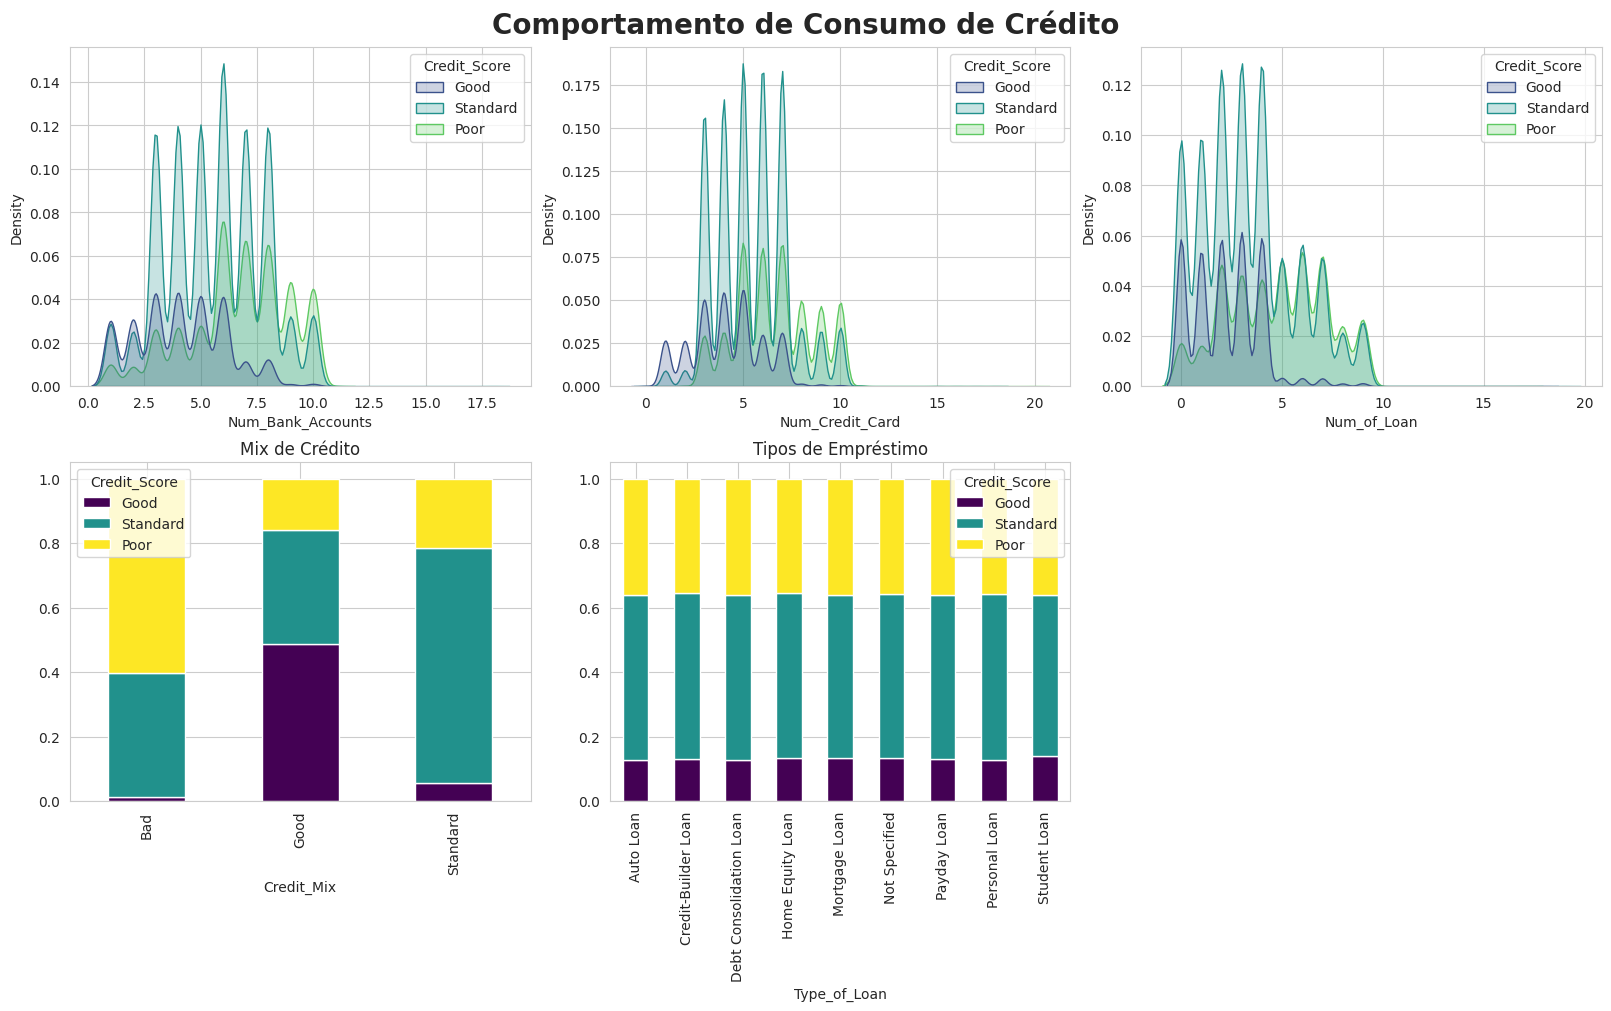

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), layout='constrained')
fig.suptitle('Comportamento de Consumo de Crédito', fontsize=20, fontweight='bold')

# Nº de Contas em Bancos
sns.kdeplot(x='Num_Bank_Accounts', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[0, 0])

# Nº de Cartões de Crédito
sns.kdeplot(x='Num_Credit_Card', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[0, 1])

# Nº de Empréstimos
sns.kdeplot(x='Num_of_Loan', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[0, 2])

# Mix de Crédito
pd.crosstab(df['Credit_Mix'], df['Credit_Score'], normalize='index')[ordem_score].plot(kind='bar', stacked=True, colormap='viridis', ax=axes[1, 0], title='Mix de Crédito')

# Tipos de Empréstimo
pd.crosstab(df_emprestimo['Type_of_Loan'], df_emprestimo['Credit_Score'], normalize='index')[ordem_score].plot(kind='bar', stacked=True, colormap='viridis', ax=axes[1, 1], title='Tipos de Empréstimo')

axes[1, 2].set_visible(False)


* *Modalidade de Empréstimo (Baixo Poder Preditivo):* O tipo específico de empréstimo contraído pelo cliente não atua, isoladamente, como um determinante de risco.

* *Volume de Contas, Cartões e Empréstimos (Variável Crítica):* O número de relacionamentos bancários e linhas de crédito ativas revelou-se um fator *decisivo*. Há uma forte correlação entre a quantidade de produtos e a qualidade do score: clientes classificados como bons mantêm um portfólio enxuto, enquanto os perfis ruins apresentam um número excessivo de contas, cartões e empréstimos simultâneos.

* *Mix de Crédito (Correlação Direta):* A diversificação saudável da carteira de crédito é um pilar essencial para a obtenção de um bom score. O mercado valoriza a capacidade do cliente de gerir diferentes modalidades de crédito de forma controlada, desde que isso não implique em um endividamento exacerbado.


#### **Insights**

> **A quantidade excessiva de cartões de crédito funciona como um gatilho para a inadimplência**: Quanto maior a quantidade de limites disponíveis em múltiplos cartões, maior é o risco de perda de controle financeiro e subsequente endividamento.

> **Menos é Mais no Risco de Crédito**: A concentração de produtos em poucas linhas de crédito é um indicador comportamental muito mais seguro do que um cliente altamente fragmentado em diversas instituições financeiras.





## 3.4. Padrão de Endividamento e Comportamento de Risco

Esta seção analisa os indicadores de alavancagem, o custo do capital tomado e a frequência com que os clientes acionam o mercado em busca de novos recursos, mapeando a dinâmica que leva ao superendividamento.


<Axes: xlabel='Num_Credit_Inquiries', ylabel='Density'>

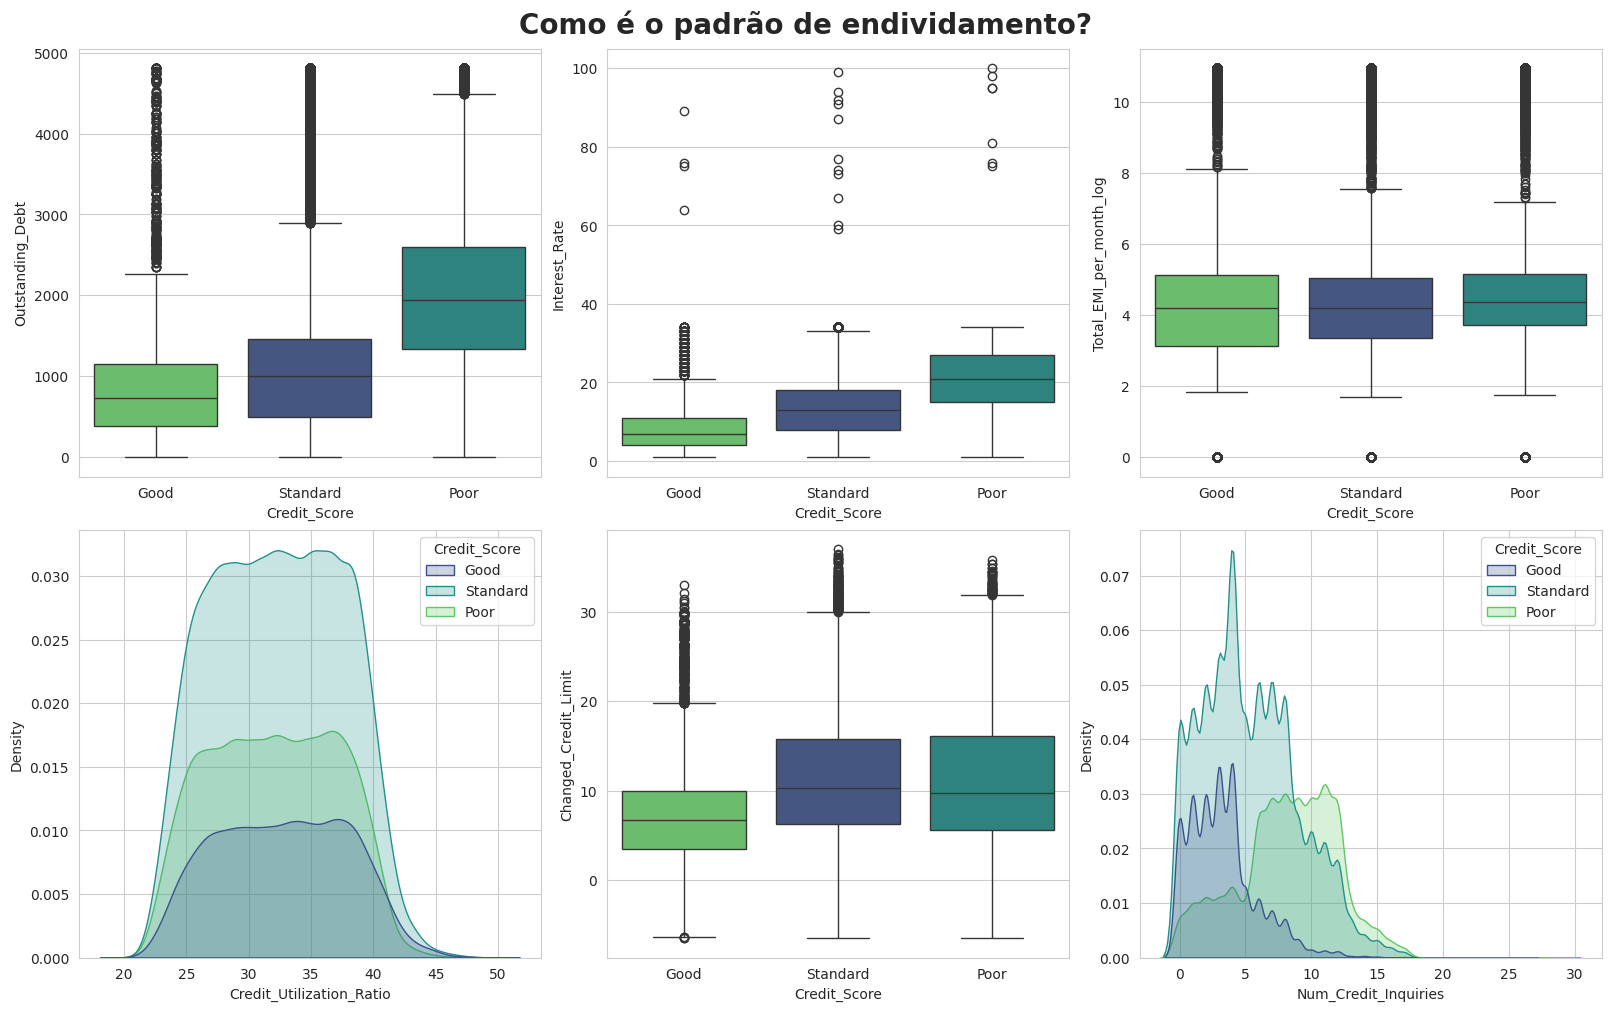

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10), layout='constrained')
fig.suptitle('Como é o padrão de endividamento?', fontsize=20, fontweight='bold')

# Débito Restante
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 0])

# Taxa de Juros
sns.boxplot(x='Credit_Score', y='Interest_Rate', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 1])

# Prestação Mensal Fixa
sns.boxplot(x='Credit_Score', y='Total_EMI_per_month_log', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 2])

# Uso de Limite
sns.kdeplot(x='Credit_Utilization_Ratio', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[1, 0])

# Mudança no Limite de Crédito
sns.boxplot(x='Credit_Score', y='Changed_Credit_Limit', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1,1])

# Número de Solicitações de Crédito
sns.kdeplot(x='Num_Credit_Inquiries', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[1, 2])


* *Utilização do Limite de Crédito (Baixo Poder Preditivo):* A taxa de utilização do limite do cartão de crédito apresenta uma distribuição semelhante entre as categorias, afetando todos os grupos de forma homogênea. Isoladamente, não é um fator diferenciador de risco.


* *Consultas de Crédito (Indicador Antecedente):* O volume de novas consultas funciona como um forte sinalizador de comportamento. Clientes com scores bons mantêm uma frequência baixa de solicitações, enquanto os perfis de risco elevado apresentam alta recorrência na busca por novos limites.


* *Dívida Pendente e Taxa de Juros (Variáveis Críticas e Decisivas):* O volume acumulado e o custo do capital são os discriminadores mais decisivos da base. Clientes de baixo risco possuem dívidas reduzidas e juros abaixo de 10%, enquanto os de alto risco carregam o triplo do endividamento e taxas na casa dos 20%.

#### **Insights:**

> **Efeito Bola de Neve**: Há uma tendência clara de que indivíduos sobrecarregados por dívidas recorram a novas consultas para obter mais crédito, tentando compensar dívidas anteriores. Como consequência dessa busca forçada por recursos, o mercado eleva as taxas de juros cobradas, o que inevitavelmente gera atrasos nos pagamentos e consolida o estado de superendividamento.



## 3.4. Padrão de Endividamento e Comportamento de Risco


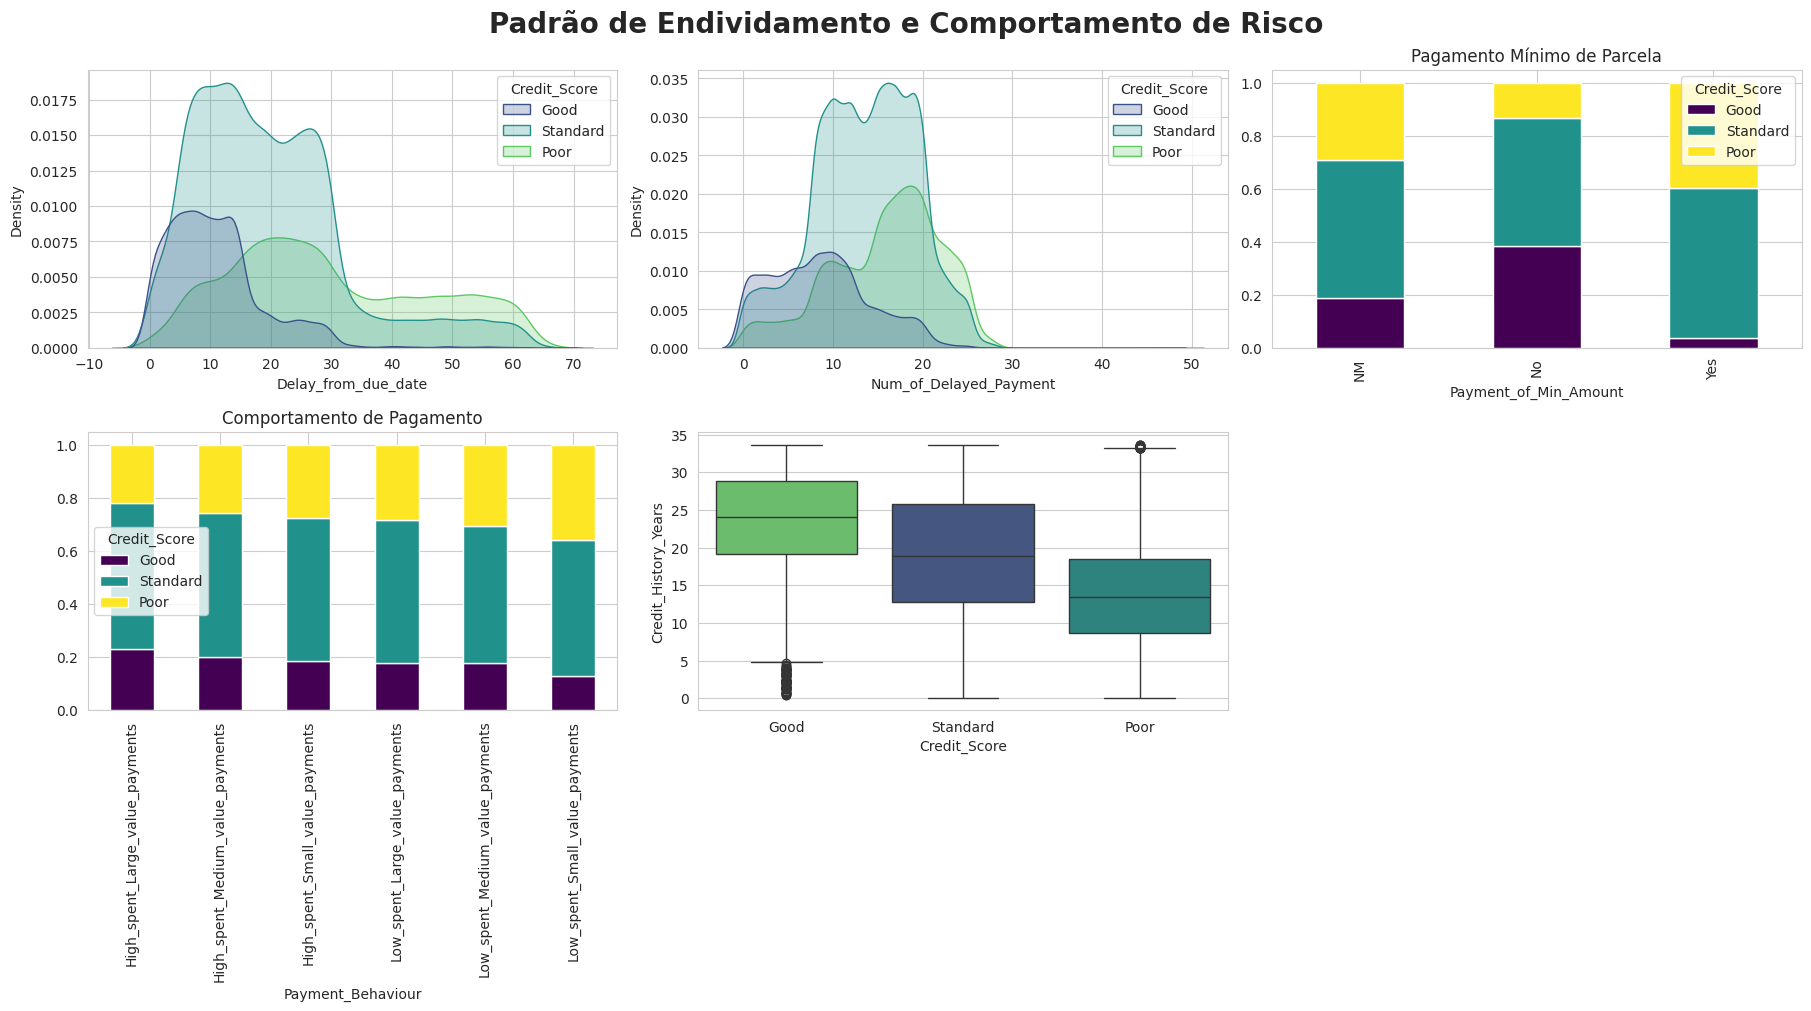

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), layout='constrained')
fig.suptitle('Padrão de Endividamento e Comportamento de Risco', fontsize=20, fontweight='bold')

# Dias de Atraso
sns.kdeplot(x='Delay_from_due_date', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[0, 0])

# Número de Pagamentos Atrasados
sns.kdeplot(x='Num_of_Delayed_Payment', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[0, 1])

# Pagamento Mínimo de Parcela
pd.crosstab(df['Payment_of_Min_Amount'], df['Credit_Score'], normalize='index')[ordem_score].plot(kind='bar', stacked=True, colormap='viridis', ax=axes[0, 2], title='Pagamento Mínimo de Parcela')

# Comportamento de Pagamento
pd.crosstab(df['Payment_Behaviour'], df['Credit_Score'], normalize='index')[ordem_score].plot(kind='bar', stacked=True, colormap='viridis', ax=axes[1, 0], title='Comportamento de Pagamento')

# 5. Anos de Histórico de Crédito
sns.boxplot(x='Credit_Score', y='Credit_History_Years', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 1])

axes[1, 2].set_visible(False)


* *Comportamento de Pagamento (Impacto Moderado):* Não há variações radicais entre as categorias comportamentais. Nota-se apenas que clientes com alto volume de gastos e pagamentos elevados concentram uma fatia levemente maior de scores bons, enquanto perfis de baixa movimentação financeira inclinam-se para scores inferiores.


* *Tempo de Histórico de Crédito (Indicador Relevante):* A maturidade do relacionamento com o mercado é um fator de forte diferenciação. A mediana do histórico de crédito para clientes com score bom atinge quase 25 anos de atuação, enquanto a dos clientes de alto risco cai praticamente pela metade.


* *Pagamento do Valor Mínimo (Variável Crítica e Decisiva):* Recorrer ao pagamento mínimo da fatura atua como gatilho direto para a degradação do perfil de crédito. Aproximadamente 40% dos clientes com score de excelência nunca recorrem ao pagamento mínimo.


* *Dias de Atraso após o Vencimento (Variável Crítica e Decisiva):* O tempo de inadimplência pontual delimita claramente as faixas de risco. Clientes com boa classificação financeira registram atrasos de no máximo 15 dias, ao passo que os perfis de risco elevado tendem a ultrapassar a barreira crítica dos 20 dias de atraso.


#### **Insights:**

> **A Confiança Requer Tempo:** A reputação financeira e a solidez de um perfil de crédito não são construídas de forma imediata; o mercado exige um histórico de exposição longo e consistente para conceder as melhores classificações.

> **Ciclo da Inadimplência Crônica:** Recorrer ao pagamento mínimo da fatura ou prolongar o atraso para além de duas semanas são os sinais mais evidentes de estresse financeiro, penalizados severamente pelos motores de decisão de crédito.


## 3.5. Correlação de Variáveis:

A análise demonstra que os comportamentos financeiros não acontecem de forma isolada. As variáveis operam em bloco, criando um verdadeiro efeito dominó que define o perfil do cliente.


Text(0.5, 1.0, 'Mapa de Calor')

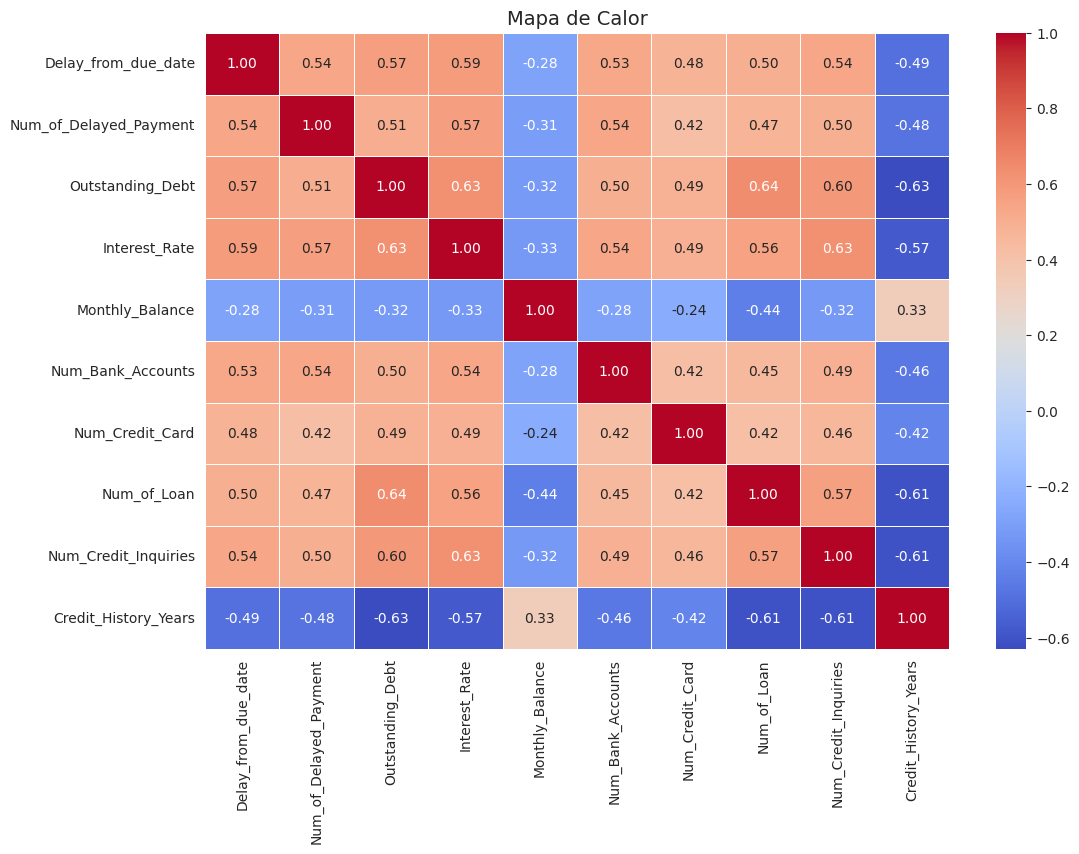

In [ ]:
variaveis_importantes = ['Delay_from_due_date','Num_of_Delayed_Payment', 'Outstanding_Debt', 'Interest_Rate', 'Monthly_Balance','Num_Bank_Accounts','Num_Credit_Card', 'Num_of_Loan', 'Num_Credit_Inquiries', 'Credit_History_Years']

matriz_corr = df[variaveis_importantes].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor', fontsize=14)



* *O Acúmulo de Produtos Financeiros:* Existe uma ligação direta entre o número de contas bancárias abertas, a quantidade de cartões de crédito, os empréstimos tomados e as consultas de crédito. Os dados mostram que clientes que expandem um desses produtos tendem a buscar os demais simultaneamente, aumentando rapidamente a sua exposição ao risco.

* *A Reação em Cadeia da Inadimplência:* Da mesma forma, os indicadores de falha no pagamento andam sempre juntos. O aumento nos dias de atraso de uma fatura está fortemente associado ao histórico geral de pagamentos atrasados. Quando o cliente começa a perder o prazo de uma conta, a probabilidade de ele atrasar os demais compromissos cresce de forma acentuada.

#### **Insights:**
> **O Efeito Dominó do Crédito:** A correlação entre essas variáveis prova que o risco financeiro não surge de um dia para o outro. Ele começa com o excesso de produtos de crédito (várias contas, cartões e empréstimos). Conforme o volume de compromissos aumenta, o controle do cliente diminui, culminando inevitavelmente na reação em cadeia dos atrasos e na queda do Score.

### Conclusão

A dinâmica comportamental do risco de crédito se comporta da seguinte forma:

> **O Valor do Tempo de Mercado:** A relações longas e estáveis com os bancos é um dos fatores mais determinantes para um Score de excelência. O tempo atua como um estabilizador natural: quanto mais longo o histórico de crédito, menor é a necessidade de pedir novos empréstimos, menor o volume de dívidas acumuladas e mais baratas são as taxas de juros cobradas, garantindo uma vida financeira segura.

> **A Espiral do Endividamento:** Em contrapartida, o superendividamento opera como um ciclo vicioso. O excesso de empréstimos e cartões faz a dívida crescer, levando o mercado a cobrar taxas de juros cada vez mais altas pelo risco. O peso dessas parcelas consome todo o dinheiro que sobraria no fim do mês, impedindo o cliente de poupar e elevando drasticamente a chance de atraso nos pagamentos.

> **O Alerta de Descontrole Financeiro:** Pressionado pelo aperto financeiro, o consumidor passa a procurar várias instituições ao mesmo tempo em busca de novos limites para cobrir as dívidas que já possui. Esse aumento repentino nas consultas de crédito funciona como o aviso claro para o mercado de que o cliente perdeu a capacidade de administrar o próprio dinheiro.


Text(0, 0.5, 'Consultas ao CPF (Inquiries)')

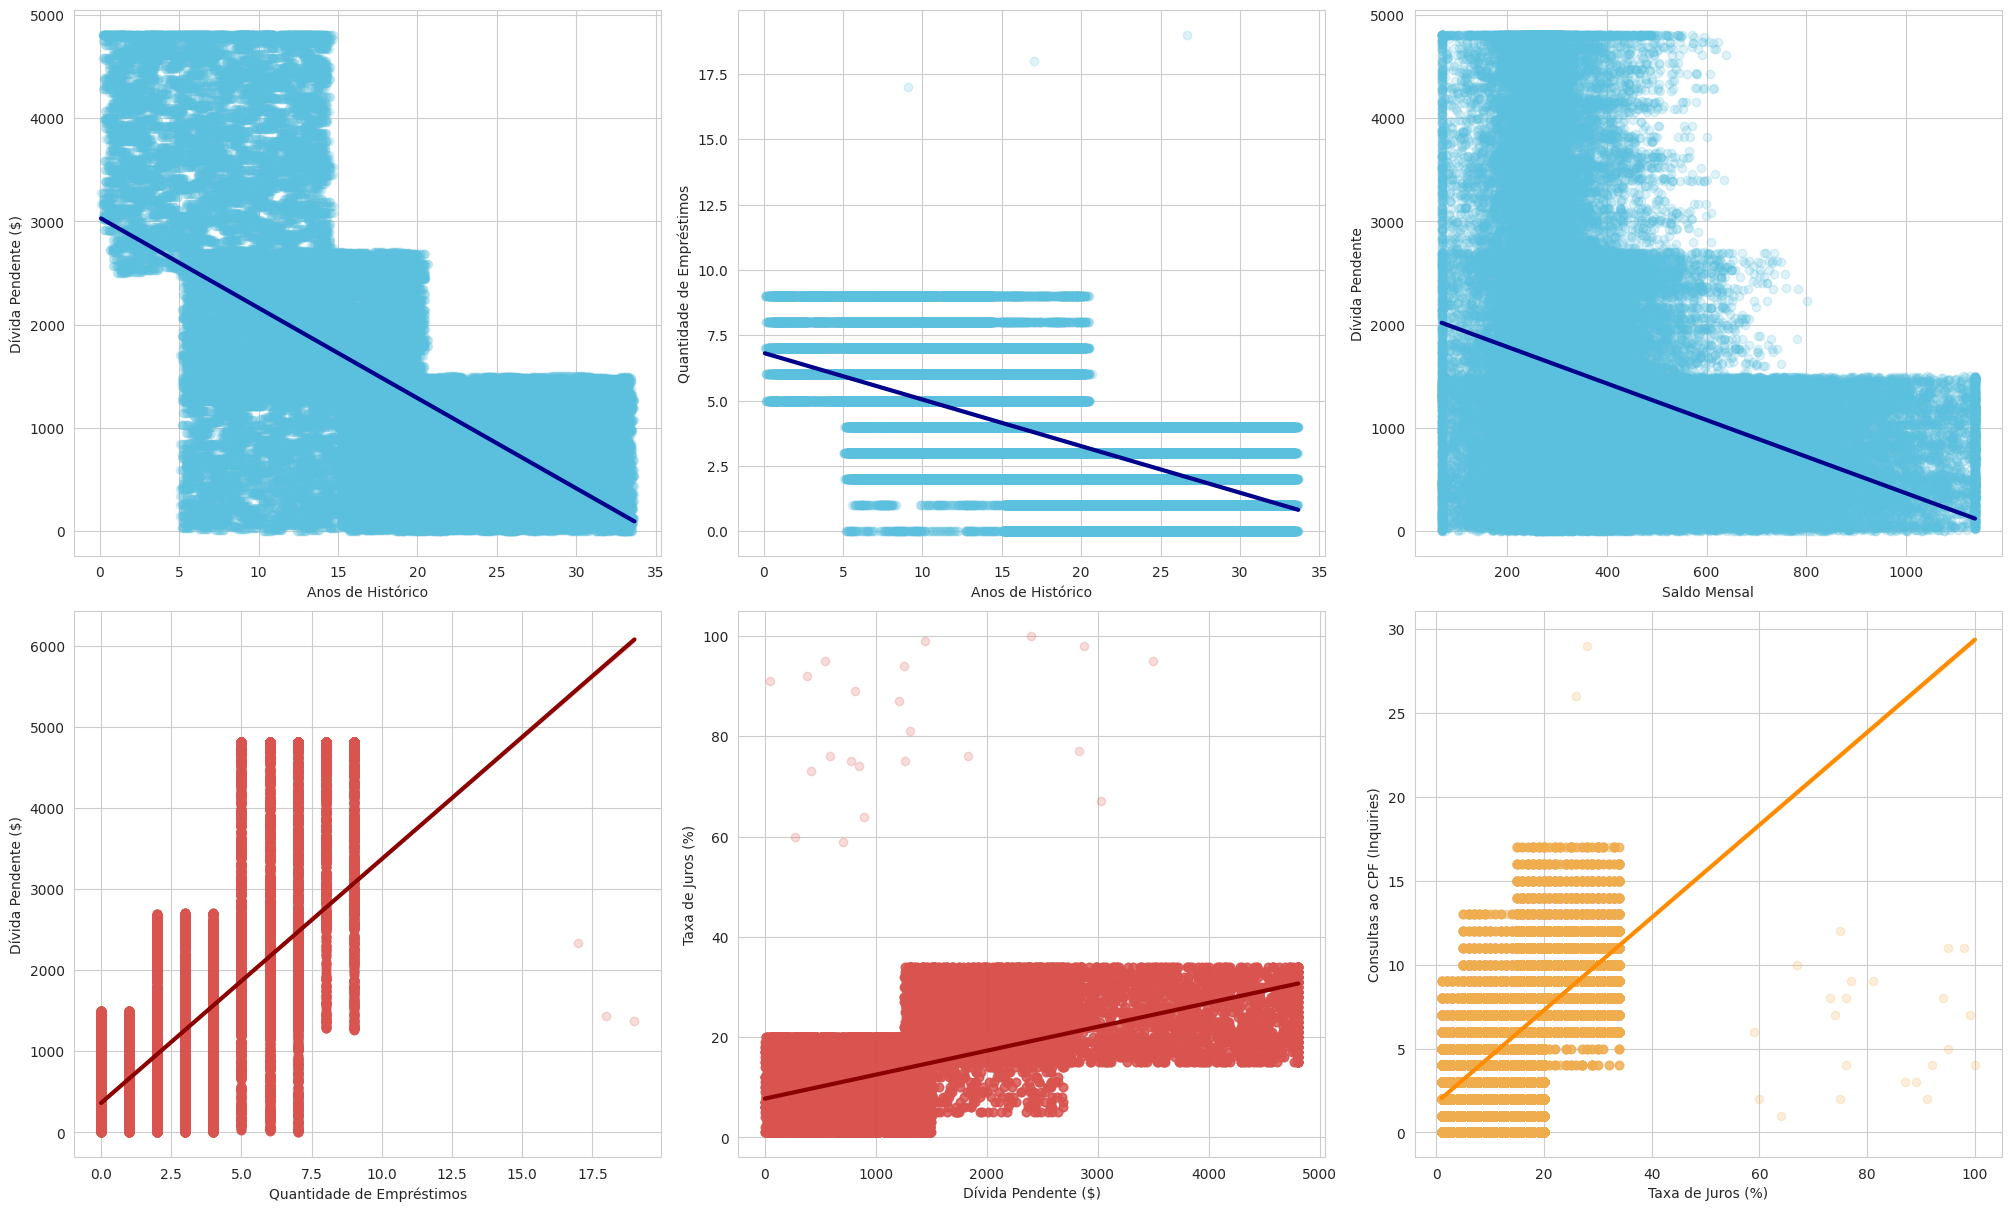

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), layout='constrained')

# 1. Histórico vs Dívida
sns.regplot(x='Credit_History_Years', y='Outstanding_Debt', data=df, ax=axes[0, 0],
            scatter_kws={'alpha':0.2, 'color':'#5bc0de'}, line_kws={'color':'darkblue', 'linewidth':3})
axes[0, 0].set_xlabel('Anos de Histórico')
axes[0, 0].set_ylabel('Dívida Pendente ($)')

# 2. Histórico vs Empréstimos
sns.regplot(x='Credit_History_Years', y='Num_of_Loan', data=df, ax=axes[0, 1],
            scatter_kws={'alpha':0.2, 'color':'#5bc0de'}, line_kws={'color':'darkblue', 'linewidth':3})
axes[0, 1].set_xlabel('Anos de Histórico')
axes[0, 1].set_ylabel('Quantidade de Empréstimos')

# 3. Histórico vs Juros

sns.regplot(x='Monthly_Balance', y='Outstanding_Debt', data=df, ax=axes[0, 2],
            scatter_kws={'alpha':0.2, 'color':'#5bc0de'}, line_kws={'color':'darkblue', 'linewidth':3})
axes[0, 2].set_xlabel('Saldo Mensal')
axes[0, 2].set_ylabel('Dívida Pendente')

# 4. Empréstimos vs Dívida Total
sns.regplot(x='Num_of_Loan', y='Outstanding_Debt', data=df, ax=axes[1, 0],
            scatter_kws={'alpha':0.2, 'color':'#d9534f'}, line_kws={'color':'darkred', 'linewidth':3})
axes[1, 0].set_xlabel('Quantidade de Empréstimos')
axes[1, 0].set_ylabel('Dívida Pendente ($)')

# 5. Dívida Total vs Taxa de Juros
sns.regplot(x='Outstanding_Debt', y='Interest_Rate', data=df, ax=axes[1, 1],
            scatter_kws={'alpha':0.2, 'color':'#d9534f'}, line_kws={'color':'darkred', 'linewidth':3})
axes[1, 1].set_xlabel('Dívida Pendente ($)')
axes[1, 1].set_ylabel('Taxa de Juros (%)')

# 6. Taxa de Juros vs Consultas por Crédito
sns.regplot(x='Interest_Rate', y='Num_Credit_Inquiries', data=df, ax=axes[1, 2],
            scatter_kws={'alpha':0.2, 'color':'#f0ad4e'}, line_kws={'color':'darkorange', 'linewidth':3})
axes[1, 2].set_xlabel('Taxa de Juros (%)')
axes[1, 2].set_ylabel('Consultas ao CPF (Inquiries)')




## Perguntas Norteadoras

### 1. Qual perfil tem maior risco de inadimplência (baixo score)?

O perfil de alto risco não é definido pelo nível de renda ou salário do cliente, mas pela ausência de gestão financeira e pelo superendividamento.

Clientes classificados com score ruim apresentam uma combinação perigosa de múltiplas linhas de crédito ativas. Devido à busca incessante por novos limites, geram um alto volume de consultas no mercado e são precificados pelas instituições com taxas de juros severas. O resultado prático é o acúmulo de uma dívida expressiva que corrói o saldo mensal. Sem fluxo de caixa livre ao fim do mês, esse perfil perde a margem de segurança financeira e entra em rota direta para a inadimplência.



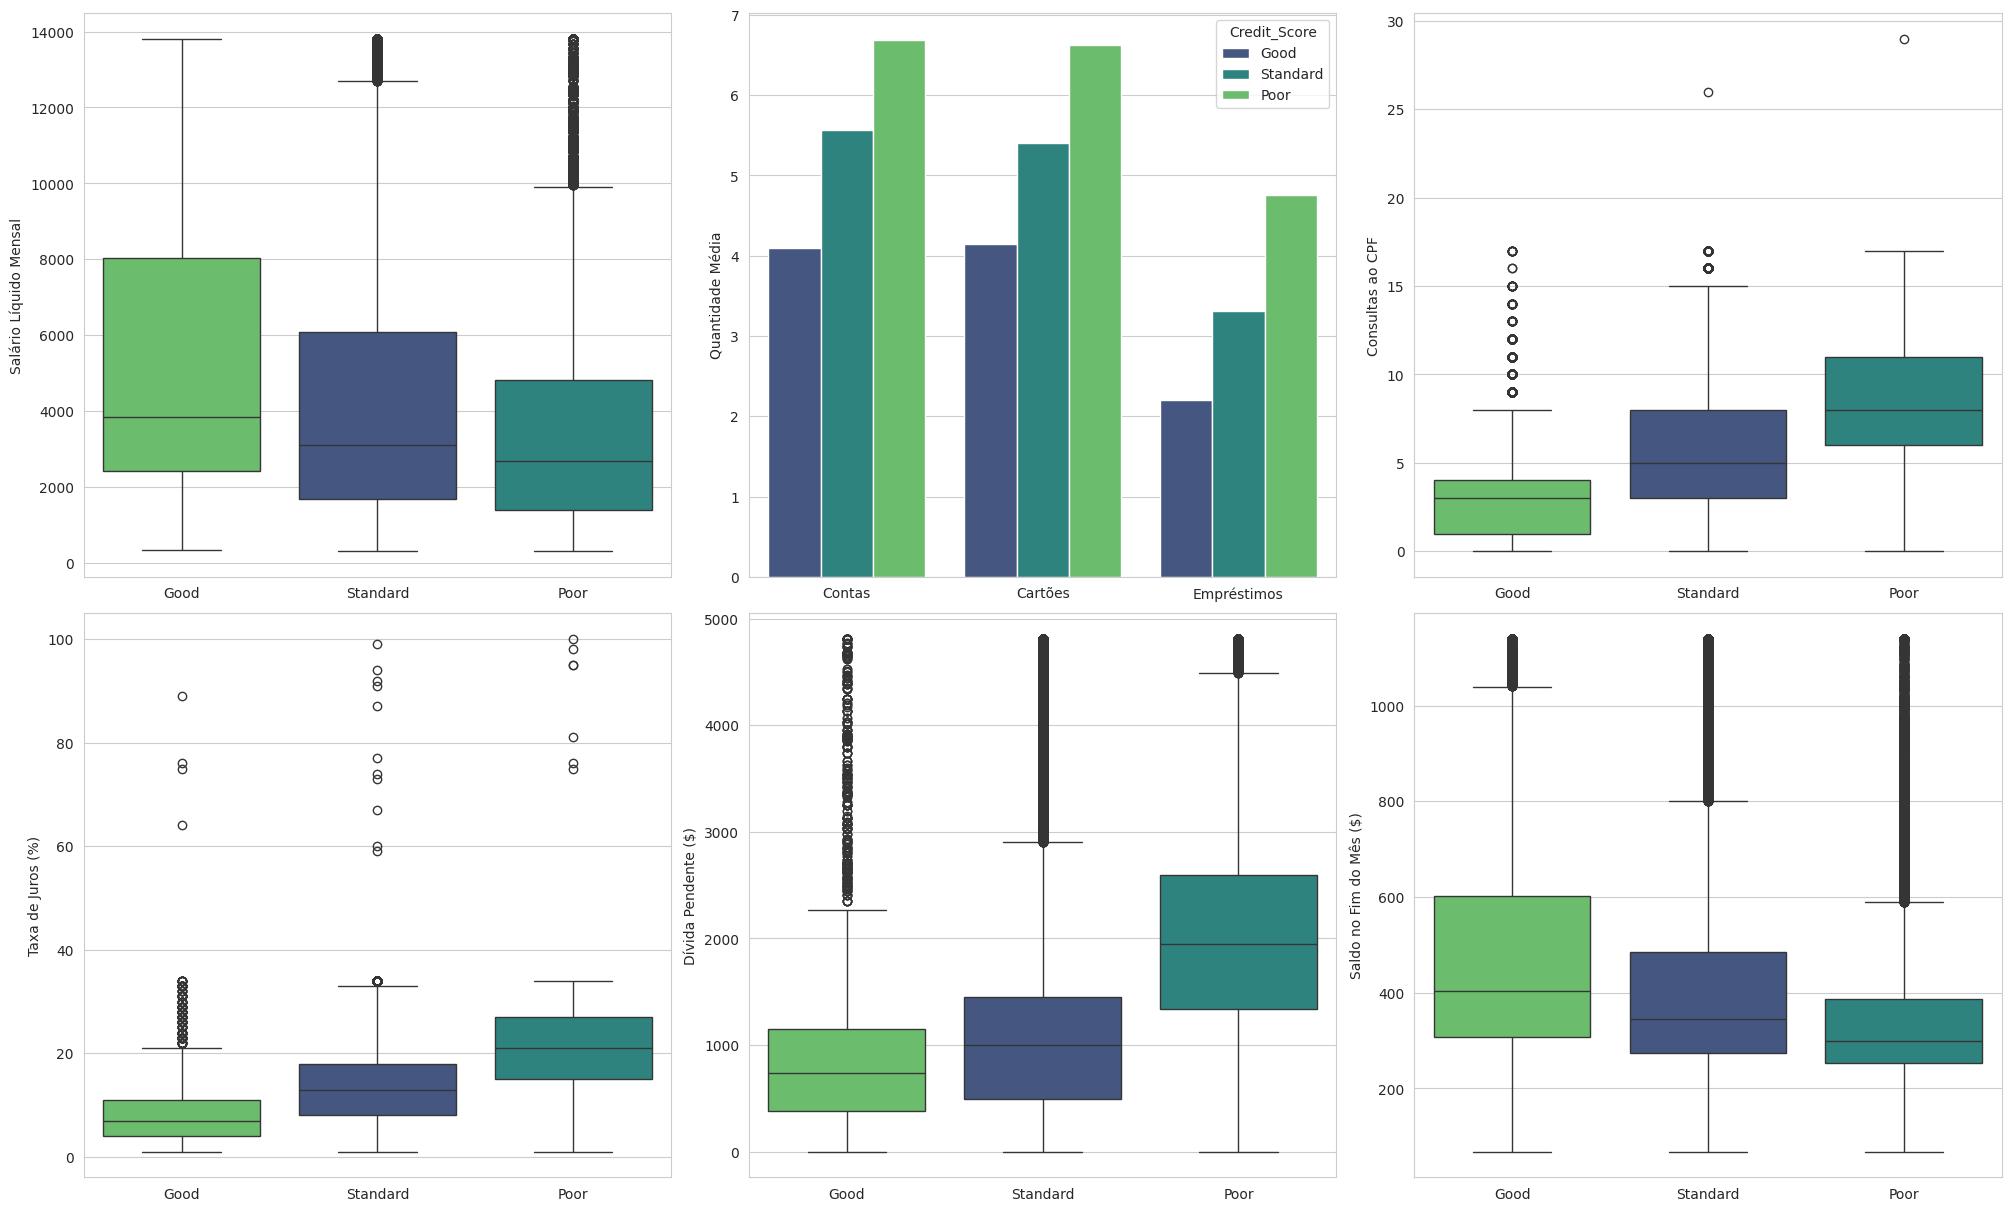

In [ ]:
sns.set_style('whitegrid')

# Para poder visualizar todos os produtos juntos
colunas_volume = ['Num_Bank_Accounts', 'Num_Credit_Card', 'Num_of_Loan']
df_vol = df.groupby('Credit_Score')[colunas_volume].mean().reset_index()
df_vol_melted = df_vol.melt(id_vars='Credit_Score', var_name='Produto', value_name='Media')
df_vol_melted['Produto'] = df_vol_melted['Produto'].replace({
    'Num_Bank_Accounts': 'Contas', 'Num_Credit_Card': 'Cartões', 'Num_of_Loan': 'Empréstimos'
})

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), layout='constrained')

# Salário
sns.boxplot(x='Credit_Score', y='Monthly_Inhand_Salary', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_ylabel('Salário Líquido Mensal')

# Nº de produtos
sns.barplot(x='Produto', y='Media', hue='Credit_Score', data=df_vol_melted, hue_order=ordem_score, palette='viridis', ax=axes[0, 1])
axes[0, 1].set_ylabel('Quantidade Média')

# Inquéritos de Crédito
sns.boxplot(x='Credit_Score', y='Num_Credit_Inquiries', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 2])
axes[0, 2].set_ylabel('Consultas ao CPF')

# Taxa de Juros
sns.boxplot(x='Credit_Score', y='Interest_Rate', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 0])
axes[1, 0].set_ylabel('Taxa de Juros (%)')

# Dívida Pendente
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 1])
axes[1, 1].set_ylabel('Dívida Pendente ($)')

# Saldo Mensal
sns.boxplot(x='Credit_Score', y='Monthly_Balance', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 2])
axes[1, 2].set_ylabel('Saldo no Fim do Mês ($)')

# Limpando os rótulos X repetitivos para deixar mais elegante
for ax in axes.flat:
    ax.set_xlabel('')

### 2. Quais fatores (exemplo: salário, idade, overtime, etc.) mais influenciam em clientes com score "Poor"?

* *Atrasos Crônicos*: A consistência no pagamento de empréstimos é a base da análise de crédito. Atrasos prolongados e recorrentes no pagamento das faturas sinalizam a quebra imediata do padrão de bom pagador e são os gatilhos mais fortes para a degradação do Score.

* *O Ciclo de Dívidas e Juros Altos*: Perfis de alto risco apresentam uma tendência de contrair novos empréstimos para pagar os antigos. Como consequência dessa forte dependência de crédito, o mercado cobra taxas de juros muito mais altas, o que faz o volume total da dívida crescer rapidamente e dificulta a recuperação financeira do cliente.

* *Baixa Maturidade Financeira*: A confiança do mercado exige tempo de validação. Clientes classificados na pior faixa de risco possuem, em média, um histórico financeiro significativamente mais curto, não oferecendo a estabilidade e a robustez necessárias para sustentar uma boa pontuação.


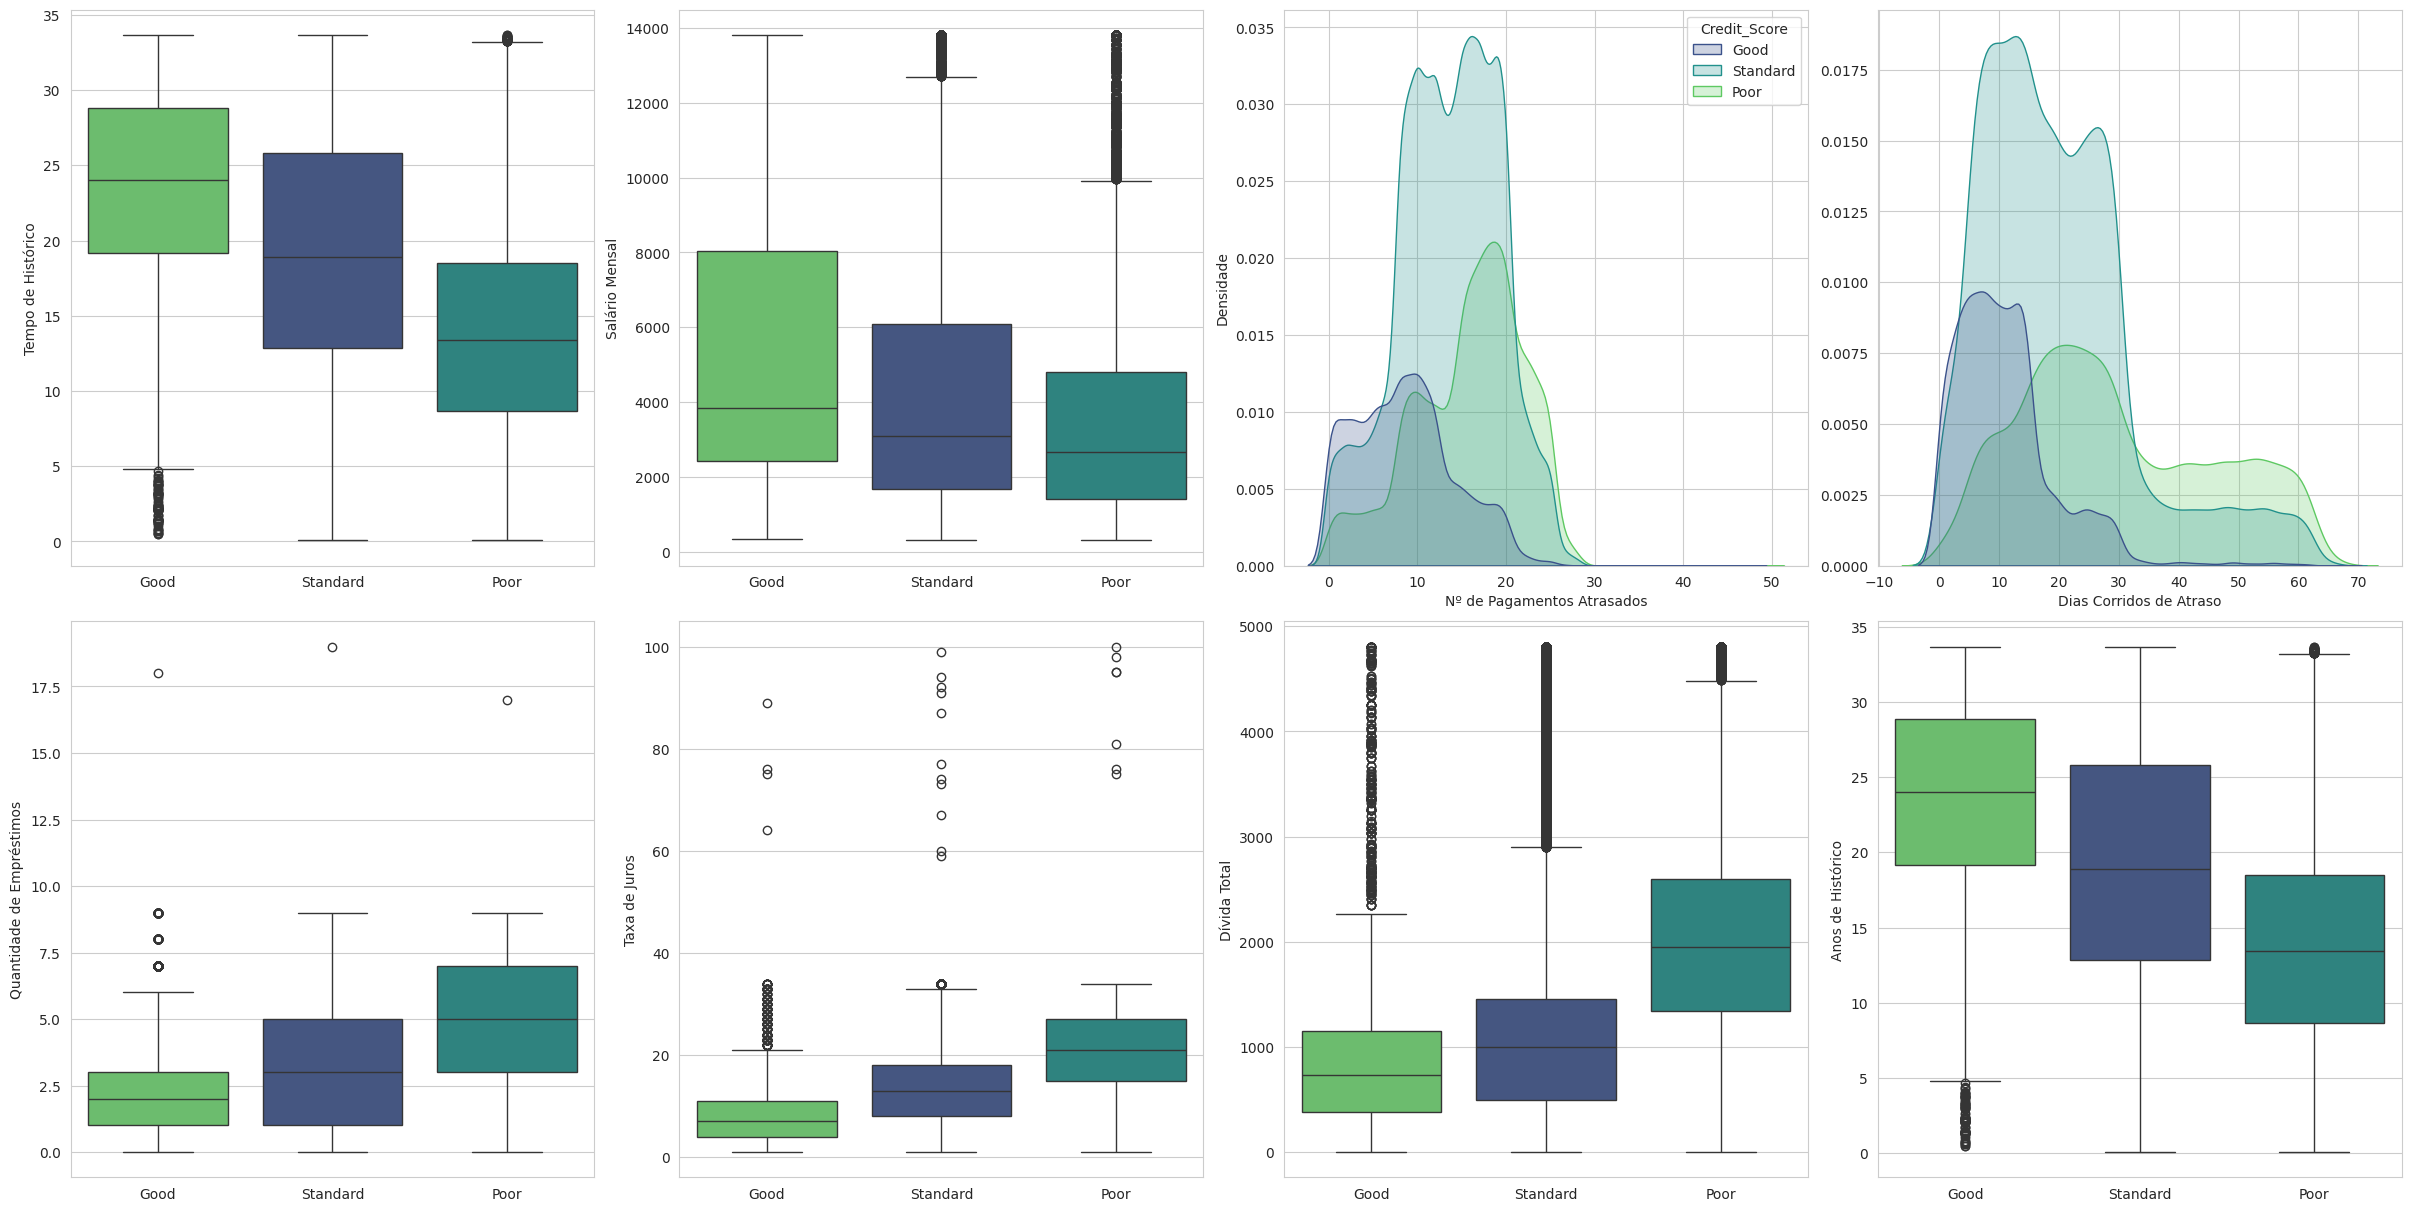

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 12), layout='constrained')

# 1. Crédito por Idade
sns.boxplot(x='Credit_Score', y='Credit_History_Years', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 0])
axes[0, 0].set_ylabel('Tempo de Histórico')

# 2. Score por salário
sns.boxplot(x='Credit_Score', y='Monthly_Inhand_Salary', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0, 1])
axes[0, 1].set_ylabel('Salário Mensal')

# 3. A Frequência de Atrasos
sns.kdeplot(x='Num_of_Delayed_Payment', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', legend=True, ax=axes[0, 2])
axes[0, 2].set_xlabel('Nº de Pagamentos Atrasados')
axes[0, 2].set_ylabel('Densidade')

# 4. Atrasos
sns.kdeplot(x='Delay_from_due_date', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', legend=False, ax=axes[0, 3])
axes[0, 3].set_xlabel('Dias Corridos de Atraso')
axes[0, 3].set_ylabel('')


# 5. Nº Empréstimos
sns.boxplot(x='Credit_Score', y='Num_of_Loan', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 0])
axes[1, 0].set_ylabel('Quantidade de Empréstimos')

#  Juros
sns.boxplot(x='Credit_Score', y='Interest_Rate', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 1])
axes[1, 1].set_ylabel('Taxa de Juros')

# Dívida
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 2])
axes[1, 2].set_ylabel('Dívida Total')

# 8. Tempo de Histórico
sns.boxplot(x='Credit_Score', y='Credit_History_Years', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[1, 3])
axes[1, 3].set_ylabel('Anos de Histórico')

# Limpando os rótulos X repetitivos de Boxplot para visual mais clean
for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1], axes[1, 2], axes[1, 3]]:
    ax.set_xlabel('')


###  3. Existe relação entre variáveis relevantes, como renda anual, quantidade de contas bancárias, número de cartões de crédito, empréstimos e classificação de score?

Sim, a análise comprova que existe uma relação direta e muito clara entre o uso de produtos de crédito, a renda e a pontuação final do cliente. Os dados revelam os seguintes insights:

* *Excesso de Crédito*: A quantidade de produtos financeiros, como contas bancárias, cartões e empréstimos, tem um impacto fortemente negativo na nota do cliente. Quanto maior o número de produtos ativos e maior o tamanho da dívida pendente, pior é a avaliação. O mercado entende que depender de muitas fontes de crédito ao mesmo tempo é um sinal claro de perda de controle.

* *Renda e Gestão Financeira*: A renda anual apresenta uma influência fraca na determinação do Score. Por outro lado, o saldo na conta, tem um impacto muito significativo e positivo na pontuação.

Portanto, o banco não avalia a confiança baseando-se apenas no quanto o cliente ganha, mas na forma como ele administra o próprio dinheiro. Um cliente com salário alto, mas que gasta tudo e acumula muitas dívidas, terá um risco muito maior do que um cliente que ganha menos, mas mantém suas contas enxutas e consegue poupar no final do mês.

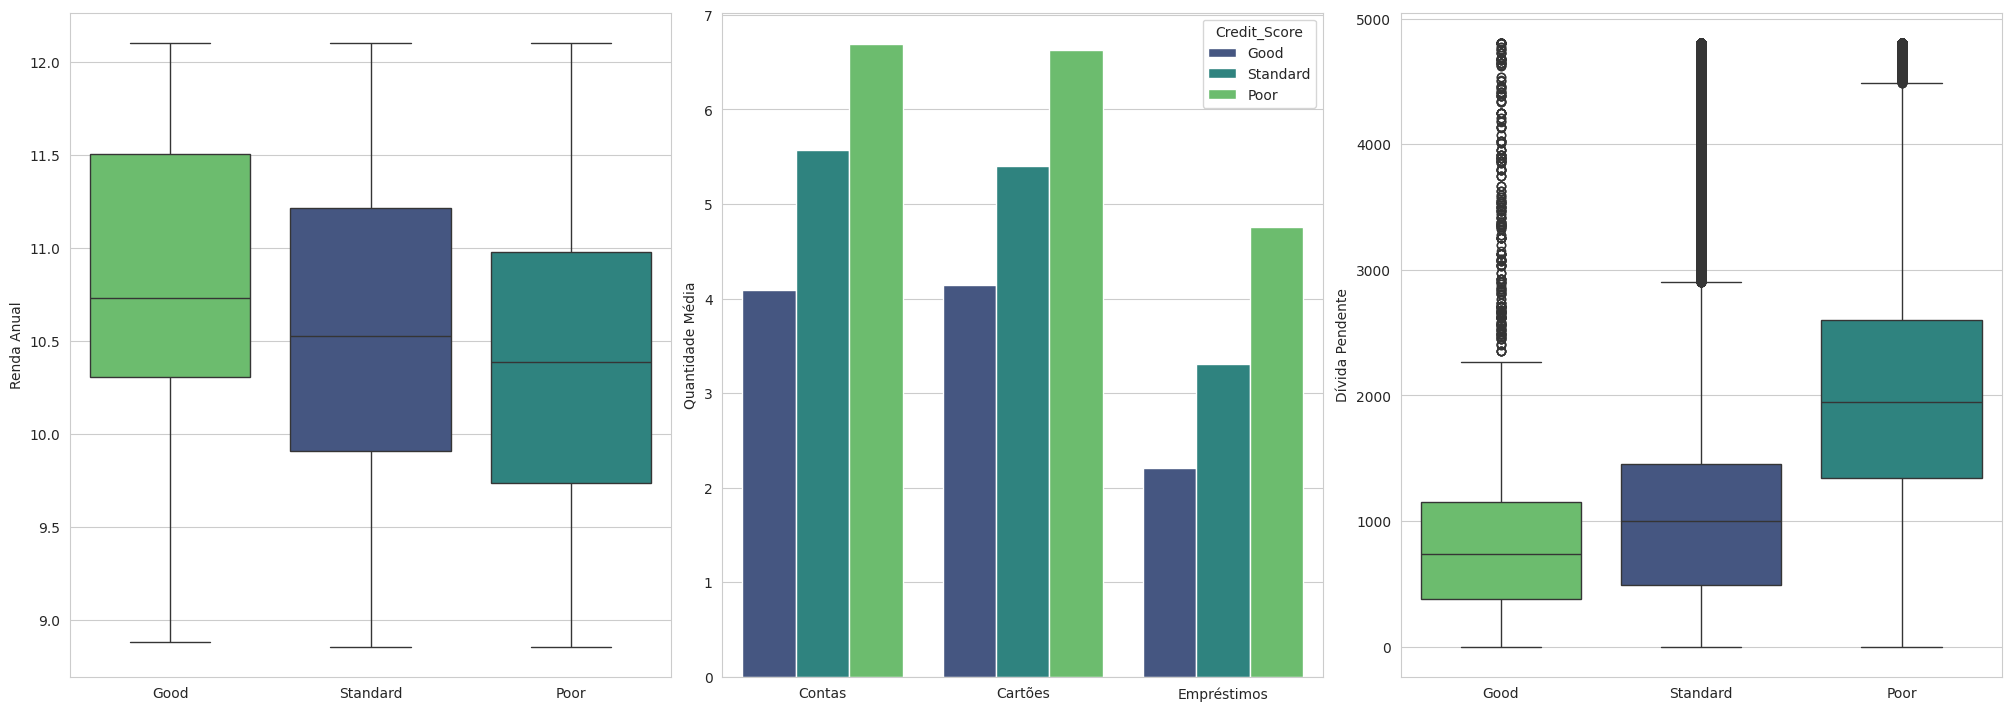

In [ ]:


sns.set_style('whitegrid')

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 7), layout='constrained')

# Renda Anual
sns.boxplot(x='Credit_Score', y='Annual_Income_log', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0])
axes[0].set_ylabel('Renda Anual')

# Uso de Crédito
sns.barplot(x='Produto', y='Media', hue='Credit_Score', data=df_vol_melted, hue_order=ordem_score, palette='viridis', ax=axes[1])
axes[1].set_ylabel('Quantidade Média')

# Dívida Pendente
sns.boxplot(x='Credit_Score', y='Outstanding_Debt', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[2])
axes[2].set_ylabel('Dívida Pendente')

# Evita Repetição

for ax in axes:
    ax.set_xlabel('')



### 4. Clientes com maior atraso médio de pagamento tendem a apresentar pior classificação de crédito?

Sim. A análise confirmou uma forte relação entre o tempo de inadimplência e a piora na avaliação do cliente. Os números revelam que os perfis de alto risco apresentam uma mediana de dias de atraso cerca de três vezes maior quando comparados aos clientes bem avaliados. Isso evidencia que o atraso constante e prolongado dos pagamentos é um dos sinais mais precisos e diretos para prever a queda na pontuação de crédito do consumidor.

Text(0, 0.5, 'Densidade de Clientes')

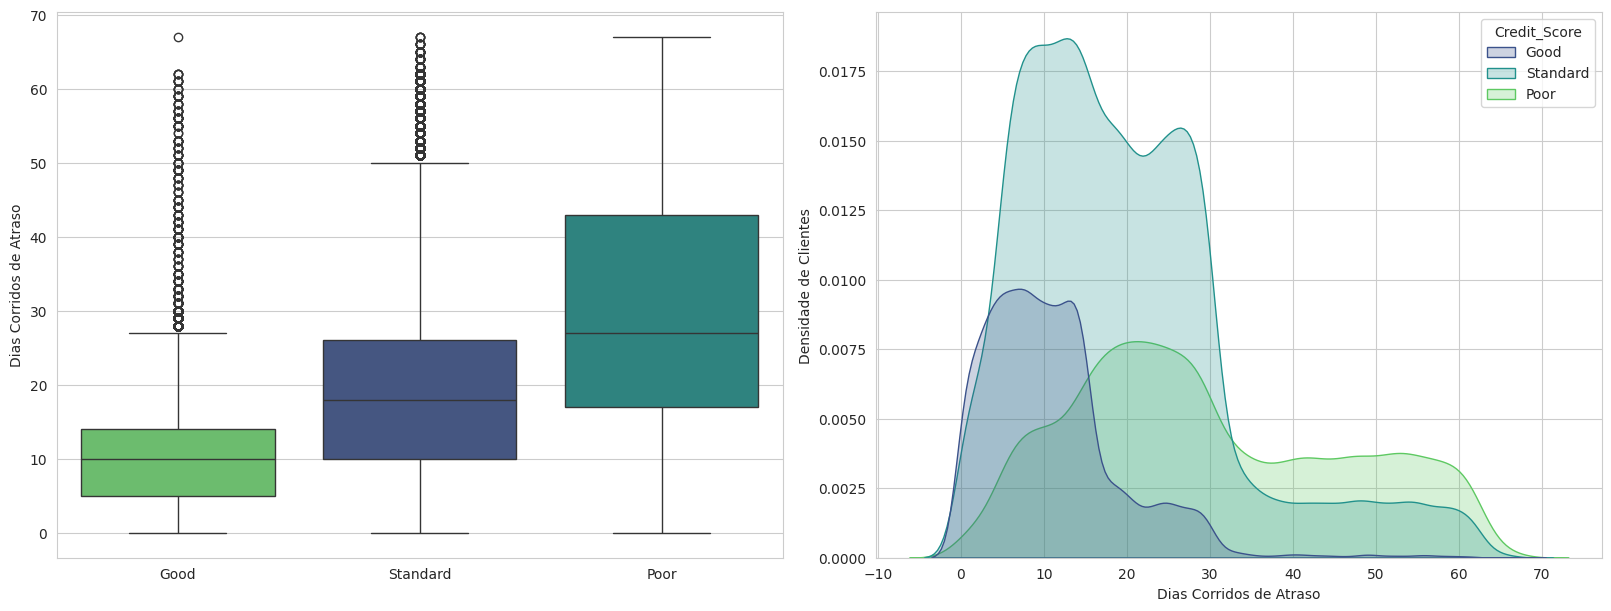

In [ ]:
sns.set_style('whitegrid')
ordem_score = ['Good', 'Standard', 'Poor']

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6), layout='constrained')

# Boxplot dos Atrasos
sns.boxplot(x='Credit_Score', y='Delay_from_due_date', data=df, order=ordem_score, hue='Credit_Score', palette='viridis', legend=False, ax=axes[0])
axes[0].set_ylabel('Dias Corridos de Atraso')
axes[0].set_xlabel('')

# Massa de Clientes por dias de atraso
sns.kdeplot(x='Delay_from_due_date', hue='Credit_Score', data=df, hue_order=ordem_score, fill=True, palette='viridis', ax=axes[1])
axes[1].set_xlabel('Dias Corridos de Atraso')
axes[1].set_ylabel('Densidade de Clientes')



### Recomendações

**Políticas de Consolidação de Crédito:** Oferecer aos clientes de score baixo a oportunidade de unificar seus vários limites de cartão de crédito e empréstimos em um único produto com uma taxa de juros mais amigável. Isso simplifica a gestão financeira do cliente e reduz a exposição ao risco.

**Trava Preventiva de Novos Produtos:** Revisar os critérios de aprovação de crédito criando um bloqueio no sistema. Se o cliente atinge um limite máximo de produtos ativos, o banco deve pausar a emissão de novos cartões, independentemente de sua renda ser alta, já que a renda não blinda o cliente contra o descontrole financeiro.

**Renegociação Proativa:** Não esperar o cliente entrar em inadimplência grave. A recomendação é criar um alerta que identifique quando a dívida pendente começa a subir rapidamente e oferecer propostas para alongar o prazo e diminuir a parcela, adequando-a ao seu salário líquido.

**Clube de Vantagens:** Implementar um programa de recompensas no aplicativo da fintech para incentivar o bom comportamento. O cliente seria premiado ao atingir metas simples, como:

* Terminar o mês com saldo positivo;

* Manter um volume mínimo de investimentos ativos;

* Pagar todas as parcelas em dia por três meses consecutivos.

*Recompensas:* O usuário acumula pontos no cartão de crédito ou ganha acesso a uma categoria de conta "Premium", que oferece taxas de juros reduzidas.

**Educação Financeira:** Criar campanhas direcionadas nas redes sociais focadas em jovens adultos para ensinar a organizar os gastos, começar a investir e criar uma relação saudável com o dinheiro. O conteúdo também deve incluir estratégias práticas para negociação de dívidas.

**Assistente Financeiro Pessoal:** Usar os dados do cliente para emitir alertas no Whatsapp:

"Notamos que suas parcelas já consomem 40% da sua renda. Cuidado com novos gastos este mês."

Isso muda o papel da fintech de cobradora para parceira da saúde financeira do usuário.


## Exportação da Base de Dados

In [ ]:
# Exportando a base principal tratada
df.to_csv("credit_score_principal.csv", index=False, encoding="utf-8")

# Exportando a base auxiliar de empréstimos
df_emprestimo.to_csv("credit_score_emprestimos.csv", index=False, encoding="utf-8")

from google.colab import files

files.download("credit_score_principal.csv")
files.download("credit_score_emprestimos.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>